<a href="https://colab.research.google.com/github/andluizsouza/unicamp-llm-agents/blob/main/modules/03_agentes_inteligentes/hands_on_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Avaliativa — Deep Agent de Planejamento de Viagem

Esta avaliação é um notebook único, com **seis tarefas encadeadas**. Cada tarefa constrói uma peça de um
*deep agent* que planeja uma viagem, e as peças se combinam na última tarefa.

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Você vai implementar:

- as **tools** locais de cálculo;
- a **integração com um servidor MCP** de clima e geolocalização (cliente, não o servidor);
- o **sistema de arquivos**, a **skill** e o **coordenador** com lista de tarefas;
- dois **subagentes**, cada um com uma técnica de planejamento diferente;
- a **integração** de tudo, com traço de execução.

Ao final, há uma seção de análise crítica, que também será avaliada (assim como uma tarefa de implementação).


## 0.1 Como esta avaliação funciona

**Encadeamento.** As tarefas dependem umas das outras: a Tarefa 3 usa o estado definido na Tarefa 2, os
subagentes das Tarefas 4 e 5 são delegados pelo coordenador da Tarefa 3, e a Tarefa 6 integra tudo. Resolva
na ordem.

**O que é avaliado.** Não há dataset e não se avalia a qualidade da viagem produzida. Avalia-se se o
**mecanismo** funciona: as funções devolvem o esperado, o subagente roda em contexto isolado, o arquivo é
gravado e relido, o plano é atualizado. E, na última seção, se você sabe justificar as escolhas.

**Células de verificação.** Depois de cada tarefa há uma célula com `assert` e checagens. Ela imprime `[OK]`
ou `[FALHOU]` para cada critério. Rode antes de seguir.

**Regras.** Consulta livre a notebooks, documentação e material da disciplina. Deixe todas as saídas salvas
no notebook entregue.


## 0.2 Pesos

| Tarefa | O que constrói (objetivo) | Peso |
|---|---|---|
| 1 | Tools locais de cálculo | 10% |
| 2 | Integração com servidor MCP (clima e geolocalização) | 10% |
| 3 | Sistema de arquivos, skill e coordenador com `write_todos` | 20% |
| 4 | Subagente de Orçamento — **ReWOO** | 25% |
| 5 | Subagente de Destino — **Tree of Thoughts** | 25% |
| 6 | Integração  | 10% |


## 0.3 Submissão

* Esta tarefa pode ser realizada individual ou em dupla.
* Apenas **um arquivo por dupla** deve ser submetido.
* Você deve entregar um arquivo do Jupyter Notebook (`.ipynb`), executado do início ao fim, com todas as
  saídas salvas, subdividido conforme as tarefas propostas nesta atividade (Tarefas 1 a 6, mais a análise
  crítica e a especificação escrita da Seção 9). Ver a Seção "8. Checklist de entrega" ao final.
* Junto do notebook, entregue também os arquivos auxiliares gerados durante a resolução — em particular
  `skills/montar-dia-de-roteiro.md` — e o arquivo de configuração do servidor MCP utilizado na Tarefa 2, se
  aplicável. Empacote tudo em um único `.zip`.
* Apenas **um integrante da equipe** deve submeter o arquivo com a solução documentada via Classroom. Nenhum outro canal de entrega será atendido. Respeitar a data e hora limite da entrega conforme descrição no Classroom.
* O arquivo (ou o `.zip`) deve ser nomeado da seguinte forma:

`atividade-deepagent-viagem-<nome_dos_integrantes>.ipynb`

(ou `.zip`, se houver arquivos auxiliares — mantendo o mesmo padrão de nome para o arquivo compactado).


## 0.4 Preenchimento do notebook resposta

* O notebook já vem estruturado por tarefa: enunciado (markdown) → célula(s) de solução → célula de
  verificação. **Não apague, mova ou renomeie** as células de enunciado nem as de verificação.
* Dentro do bloco de cada tarefa, você pode **adicionar quantas células de código ou markdown quiser**
  (funções auxiliares, testes intermediários, explicações do raciocínio, `print`s de depuração etc.). O
  único requisito é que, ao final do bloco da tarefa — antes da célula de verificação correspondente —
  todos os nomes exigidos (funções, classes, variáveis como `coordenador`, `subagente_orcamento`, `T`, ...)
  estejam definidos exatamente com o nome usado nas checagens (`verificar(...)`), pois é isso que a
  verificação importa do namespace do notebook.
* Pode reorganizar livremente as células **dentro do bloco de uma mesma tarefa**, mas não mova células de
  solução para o bloco de outra tarefa — a numeração e o encadeamento dependem da ordem das tarefas.
* Se precisar de uma biblioteca além das já instaladas, adicione-a na célula `%pip install` da Seção 0.7
  (Preparação do ambiente), não em uma célula solta no meio de uma tarefa.
* Células de texto explicando decisões de projeto são bem-vindas, mas não substituem código funcional —
  o que é avaliado é o comportamento verificado pela célula `verificar(...)` de cada tarefa.
* Antes de entregar, rode o notebook do início ao fim em uma sessão limpa (**Kernel/Runtime → Restart and
  Run All**) para garantir que ele funciona na ordem em que será corrigido, e deixe todas as saídas salvas.


## 0.5 O cenário

O cenário é **fixo e igual para todos**. Não altere os valores — as verificações dependem deles.

> **Viagem:** duas pessoas saindo de São Paulo (GRU), de **12 a 19 de outubro de 2026**.
> **Orçamento total:** R$ 12.000,00, incluindo passagens, hospedagem, transporte local e alimentação.
> **Interesses:** gastronomia, museus e natureza urbana.
> **Restrição 1:** um dos viajantes tem mobilidade reduzida — trajetos a pé acima de 2 km e atrações sem
> acessibilidade devem ser evitados.
> **Restrição 2:** no dia **15 de outubro** há um feriado local no destino, com a maior parte dos museus e
> comércio fechados.
> **Destinos candidatos:** Buenos Aires, Santiago e Montevidéu. O agente deve escolher **um**.

Os candidatos são fixos de propósito: isso torna a árvore de decisão da Tarefa 6 comparável entre todos.

## 0.6 Mapa das tarefas

1. Tools locais de cálculo.
2. Integração com um servidor MCP de clima e geolocalização (Open-Meteo / Nominatim).
3. Sistema de arquivos, skill e coordenador.
4. Subagente de Orçamento com ReWOO.
5. Subagente de Destino com Tree of Thoughts.
6. Integração e traço de execução.
7. Análise crítica.
8. Especificação escrita (Plan-and-Execute e Reflection).

> As Seções 7 e 8 (análise crítica e especificação escrita) são referenciadas no checklist de entrega, mas
> ainda não têm células próprias neste notebook — adicione-as antes de aplicar esta avaliação, com as
> perguntas específicas que você quer que os alunos respondam.


---

## 0.7 Preparação do ambiente

**Não modifique as células desta seção.** Apenas execute-as na ordem — elas definem funções auxiliares e
utilitários de verificação usados por todas as tarefas.


In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langchain langchain-core langgraph langchain-openai python-dotenv pydantic rich
%pip install -U mcp langchain-mcp-adapters httpx
%pip install -U deepagents

  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached anyio-4.14.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached sniffio-1.

In [2]:
from __future__ import annotations

import asyncio
import json
import os
from datetime import date, datetime, timedelta
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.tools import tool as tool_decorator
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import InjectedToolCallId

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from IPython.display import Image, display
from rich import print
from rich.markdown import Markdown

In [3]:
def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_json(value: Any) -> None:
    print(json.dumps(value, ensure_ascii=False, indent=2, default=str))


def print_messages(messages: List[BaseMessage]) -> None:
    for index, message in enumerate(messages):
        print(f"\nMensagem {index} — {message.__class__.__name__}")
        if isinstance(message, AIMessage) and message.tool_calls:
            print("tool_calls:", [c["name"] for c in message.tool_calls])
        else:
            conteudo = str(message.content)
            print(conteudo[:300] + (" [...]" if len(conteudo) > 300 else ""))


def contar_tokens_aproximado(messages: List[BaseMessage]) -> int:
    total = 0
    for m in messages:
        total += len(str(m.content))
        if isinstance(m, AIMessage) and m.tool_calls:
            total += len(json.dumps(m.tool_calls, ensure_ascii=False))
    return total // 4


_RESULTADOS_VERIFICACAO: Dict[str, List[bool]] = {}


def verificar(tarefa: str, criterio: str, condicao: bool, detalhe: str = "") -> None:
    """Registra e imprime o resultado de um critério de verificação."""
    _RESULTADOS_VERIFICACAO.setdefault(tarefa, []).append(bool(condicao))
    marca = "[OK]     " if condicao else "[FALHOU] "
    print(f"{marca}{criterio}" + (f"  ->  {detalhe}" if detalhe and not condicao else ""))


def resumo_verificacoes() -> None:
    print("\n=== RESUMO DAS VERIFICAÇÕES ===")
    for tarefa, resultados in _RESULTADOS_VERIFICACAO.items():
        print(f"{tarefa:34} {sum(resultados)}/{len(resultados)} critérios")

In [4]:
load_dotenv()
print("Chave GOOGLE_API_KEY configurada." if "GOOGLE_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model(model="google_genai:gemini-3.7-flash", temperature=0.0)

Chave GOOGLE_API_KEY configurada.

### Dados do cenário

**Não modifique os dicionários abaixo (`CENARIO`, `CATALOGO_VOOS`, `CATALOGO_HOSPEDAGENS`,
`CUSTOS_DIARIOS_BRL`, `COORDENADAS`).** Estes dados são fornecidos. O catálogo de voos e hospedagens é
**fictício e controlado**, para que a avaliação não dependa de APIs de reserva que mudam ou bloqueiam acesso.
As células de verificação dependem exatamente destes valores.


In [31]:
# NÃO MODIFIQUE ESTE BLOCO — valores fixos usados pelas verificações de todas as tarefas.
CENARIO = {
    "origem": "São Paulo",
    "origem_iata": "GRU",
    "data_ida": "2026-10-12",
    "data_volta": "2026-10-19",
    "viajantes": 2,
    "orcamento_total_brl": 12000.00,
    "interesses": ["gastronomia", "museus", "natureza urbana"],
    "restricoes": [
        "um viajante com mobilidade reduzida: evitar trajetos a pé acima de 2 km e atrações sem acessibilidade",
        "feriado local em 2026-10-15: museus e comércio majoritariamente fechados",
    ],
    "candidatos": ["Buenos Aires", "Santiago", "Montevidéu"],
}

CATALOGO_VOOS = {
    "Buenos Aires": {"iata": "EZE", "preco_brl": 1850.00, "duracao_h": 2.8, "escalas": 0},
    "Santiago":     {"iata": "SCL", "preco_brl": 2300.00, "duracao_h": 4.2, "escalas": 0},
    "Montevidéu":   {"iata": "MVD", "preco_brl": 2050.00, "duracao_h": 3.1, "escalas": 1},
}

CATALOGO_HOSPEDAGENS = {
    "Buenos Aires": [
        {"nome": "Hotel Recoleta", "diaria_brl": 420.00, "acessivel": True,  "nota": 8.6},
        {"nome": "Hostel Palermo", "diaria_brl": 180.00, "acessivel": False, "nota": 8.1},
    ],
    "Santiago": [
        {"nome": "Hotel Providencia", "diaria_brl": 480.00, "acessivel": True,  "nota": 8.8},
        {"nome": "Apart Bellas Artes", "diaria_brl": 310.00, "acessivel": True, "nota": 8.3},
    ],
    "Montevidéu": [
        {"nome": "Hotel Pocitos", "diaria_brl": 350.00, "acessivel": True,  "nota": 8.4},
        {"nome": "Pousada Ciudad Vieja", "diaria_brl": 240.00, "acessivel": False, "nota": 7.9},
    ],
}

CUSTOS_DIARIOS_BRL = {
    "Buenos Aires": {"alimentacao": 180.00, "transporte_local": 60.00},
    "Santiago":     {"alimentacao": 210.00, "transporte_local": 80.00},
    "Montevidéu":   {"alimentacao": 190.00, "transporte_local": 55.00},
}

COORDENADAS = {
    "Buenos Aires": (-34.6037, -58.3816),
    "Santiago":     (-33.4489, -70.6693),
    "Montevidéu":   (-34.9011, -56.1645),
}

print_json(CENARIO)

{
  "origem": "São Paulo",
  "origem_iata": "GRU",
  "data_ida": "2026-10-12",
  "data_volta": "2026-10-19",
  "viajantes": 2,
  "orcamento_total_brl": 12000.0,
  "interesses": [
    "gastronomia",
    "museus",
    "natureza urbana"
  ],
  "restricoes": [
    "um viajante com mobilidade reduzida: evitar trajetos a pé acima de 2 km e atrações sem acessibilidade",
    "feriado local em 2026-10-15: museus e comércio majoritariamente fechados"
  ],
  "candidatos": [
    "Buenos Aires",
    "Santiago",
    "Montevidéu"
  ]
}

# Tarefa 1 — Tools locais de cálculo *(10%)*

As tools desta tarefa são **puras**: recebem argumentos, calculam e devolvem. Nenhuma acessa rede, nenhuma lê
o estado do grafo. É a camada determinística do agente.

Implemente as quatro tools abaixo, com o decorador `@tool_decorator`. Todas devem devolver **string JSON**
com `ensure_ascii=False`, seguindo a convenção dos notebooks da disciplina.

**`calcular_dias(data_inicio, data_fim)`**
Devolve `{"dias": N, "noites": N-1}`. Datas no formato `YYYY-MM-DD`. Se `data_fim` for anterior a
`data_inicio`, devolva `{"erro": "datas_invalidas"}`.

**`somar_orcamento(itens)`**
Recebe uma lista de dicionários com `categoria` e `valor_brl`. Devolve
`{"total_brl": T, "por_categoria": {...}}`, com os valores arredondados em duas casas.

**`tempo_deslocamento(distancia_km, modal)`**
Modais e velocidades médias: `"a_pe"` 4 km/h, `"transporte_publico"` 18 km/h, `"taxi"` 25 km/h. Devolve
`{"minutos": M, "modal": modal}`, com `M` inteiro arredondado. Modal desconhecido devolve
`{"erro": "modal_invalido", "modais_disponiveis": [...]}`.

**`validar_datas_roteiro(roteiro)`**
Recebe uma lista de dicionários com `data` e `atividades`. Devolve
`{"valido": bool, "conflitos": [...]}`. Conta como conflito: data duplicada, data fora do intervalo da
viagem, e dia sem nenhuma atividade.

In [6]:
# Escreva sua solução aqui.

@tool_decorator
def calcular_dias(data_inicio: str, data_fim: str) -> str:
    """
    Calcula o número de dias e noites entre duas datas no formato 'YYYY-MM-DD'.
    Args:
        data_inicio (str): Data de início no formato 'YYYY-MM-DD'.
        data_fim (str): Data de fim no formato 'YYYY-MM-DD'.
    Returns:
        str: JSON contendo o número de dias e noites, ou uma mensagem de erro se as datas forem inválidas.
    """

    try:
        d1 = datetime.strptime(data_inicio, '%Y-%m-%d').date()
        d2 = datetime.strptime(data_fim, '%Y-%m-%d').date()
    except Exception:
        return json.dumps({'erro': 'datas_invalidas'}, ensure_ascii=False)
    if d2 < d1:
        return json.dumps({'erro': 'datas_invalidas'}, ensure_ascii=False)
    dias = (d2 - d1).days + 1  # inclusive
    noites = max(0, dias - 1)

    return json.dumps({'dias': dias, 'noites': noites}, ensure_ascii=False)

@tool_decorator
def somar_orcamento(itens: list) -> str:
    """
    Calcula o total de orçamento e o total por categoria a partir de uma lista de itens.
    Args:
        itens (list): Lista de dicionários, cada um contendo 'categoria' e 'valor_brl'.
    Returns:
        str: JSON contendo o total de orçamento e o total por categoria.
    """

    total = 0.0
    por_cat: Dict[str, float] = {}
    for it in itens:
        cat = it.get('categoria')
        val = float(it.get('valor_brl', 0))
        total += val
        por_cat[cat] = por_cat.get(cat, 0.0) + val
    # Garantir float + Arredondar saída final
    total = round(total + 1e-9, 2)
    por_cat = {k: round(v + 1e-9, 2) for k, v in por_cat.items()}

    return json.dumps({'total_brl': total, 'por_categoria': por_cat}, ensure_ascii=False)

@tool_decorator
def tempo_deslocamento(distancia_km: float, modal: str) -> str:
    """
    Calcula o tempo de deslocamento em minutos com base na distância e no modal de transporte.
    Args:
        distancia_km (float): Distância em quilômetros.
        modal (str): Modal de transporte ('a_pe', 'transporte_publico', 'taxi').
    Returns:
        str: JSON contendo o tempo de deslocamento em minutos, ou uma mensagem de erro se o modal for inválido.
    """

    velocidades = {'a_pe': 4.0, 'transporte_publico': 18.0, 'taxi': 25.0}
    if modal not in velocidades:
        return json.dumps({'erro': 'modal_invalido', 'modais_disponiveis': list(velocidades.keys())}, ensure_ascii=False)
    vel = velocidades[modal]
    minutos = int(round((float(distancia_km) / vel) * 60.0))

    return json.dumps({'minutos': minutos, 'modal': modal}, ensure_ascii=False)

@tool_decorator
def validar_datas_roteiro(roteiro: list) -> str:
    """
    Valida as datas de um roteiro de viagem, verificando duplicatas, intervalo da viagem e atividades.
    Args:
        roteiro (list): Lista de dicionários, cada um contendo 'data' e 'atividades'.
    Returns:
        str: JSON contendo se o roteiro é válido e uma lista de conflitos encontrados.
    """

    conflitos: List[str] = []
    datas = [r.get('data') for r in roteiro]
    # Duplicatas
    seen = {}
    for d in datas:
        seen[d] = seen.get(d, 0) + 1
    for d, c in seen.items():
        if c > 1:
            conflitos.append(f'data_duplicada:{d}')
    # Intervalo da viagem
    ida = datetime.strptime(CENARIO['data_ida'], '%Y-%m-%d').date()
    volta = datetime.strptime(CENARIO['data_volta'], '%Y-%m-%d').date()
    for r in roteiro:
        try:
            d = datetime.strptime(r.get('data'), '%Y-%m-%d').date()
        except Exception:
            conflitos.append(f'data_invalida:{r.get("data")}')
            continue
        if d < ida or d > volta:
            conflitos.append(f'data_fora_intervalo:{r.get("data")}')
        atividades = r.get('atividades') or []
        if len(atividades) == 0:
            conflitos.append(f'dia_sem_atividades:{r.get("data" )}')
    valido = len(conflitos) == 0
    return json.dumps({'valido': valido, 'conflitos': conflitos}, ensure_ascii=False)

### Verificação — Tarefa 1

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [7]:
T = "Tarefa 1 — tools locais"

r = json.loads(calcular_dias.invoke({"data_inicio": "2026-10-12", "data_fim": "2026-10-19"}))
verificar(T, "calcular_dias conta 8 dias e 7 noites", r.get("dias") == 8 and r.get("noites") == 7, str(r))

r = json.loads(calcular_dias.invoke({"data_inicio": "2026-10-19", "data_fim": "2026-10-12"}))
verificar(T, "calcular_dias rejeita datas invertidas", r.get("erro") == "datas_invalidas", str(r))

itens = [
    {"categoria": "passagem", "valor_brl": 1850.0},
    {"categoria": "hospedagem", "valor_brl": 2940.0},
    {"categoria": "passagem", "valor_brl": 1850.0},
]
r = json.loads(somar_orcamento.invoke({"itens": itens}))
verificar(T, "somar_orcamento totaliza corretamente", abs(r.get("total_brl", 0) - 6640.0) < 0.01, str(r))
verificar(T, "somar_orcamento agrupa por categoria",
          abs(r.get("por_categoria", {}).get("passagem", 0) - 3700.0) < 0.01, str(r))

r = json.loads(tempo_deslocamento.invoke({"distancia_km": 6, "modal": "transporte_publico"}))
verificar(T, "tempo_deslocamento calcula 6 km de transporte público", r.get("minutos") == 20, str(r))

r = json.loads(tempo_deslocamento.invoke({"distancia_km": 3, "modal": "helicoptero"}))
verificar(T, "tempo_deslocamento rejeita modal inválido", r.get("erro") == "modal_invalido", str(r))

roteiro_ok = [{"data": f"2026-10-{d}", "atividades": ["visita"]} for d in range(12, 20)]
r = json.loads(validar_datas_roteiro.invoke({"roteiro": roteiro_ok}))
verificar(T, "validar_datas_roteiro aceita roteiro válido", r.get("valido") is True, str(r))

roteiro_ruim = [
    {"data": "2026-10-12", "atividades": ["visita"]},
    {"data": "2026-10-12", "atividades": ["outra"]},
    {"data": "2026-11-01", "atividades": ["fora do intervalo"]},
    {"data": "2026-10-14", "atividades": []},
]
r = json.loads(validar_datas_roteiro.invoke({"roteiro": roteiro_ruim}))
verificar(T, "validar_datas_roteiro detecta os três tipos de conflito",
          r.get("valido") is False and len(r.get("conflitos", [])) >= 3, str(r))

[OK]     calcular_dias conta 8 dias e 7 noites

[OK]     calcular_dias rejeita datas invertidas

[OK]     somar_orcamento totaliza corretamente

[OK]     somar_orcamento agrupa por categoria

[OK]     tempo_deslocamento calcula 6 km de transporte público

[OK]     tempo_deslocamento rejeita modal inválido

[OK]     validar_datas_roteiro aceita roteiro válido

[OK]     validar_datas_roteiro detecta os três tipos de conflito

# Tarefa 2 — Integração com servidor MCP *(10%)*

Nesta tarefa você **conecta-se, como cliente**, a um servidor MCP que expõe dados reais de clima e
geolocalização. Você não precisa escrever o lado servidor do protocolo — use um servidor MCP público e
gratuito para Open-Meteo/Nominatim (por exemplo, algum dos listados em
[mcpservers.org](https://mcpservers.org) ou o indicado pela disciplina), rodando localmente via `npx` ou
`uvx`, sem chave de acesso.

O servidor deve expor, no mínimo, duas capacidades equivalentes a:

**`geocodificar(local)`** — converte um nome de lugar em coordenadas (Nominatim/OpenStreetMap).

**`prever_clima(latitude, longitude, data_inicio, data_fim)`** — obtém a previsão diária de temperatura e
precipitação (Open-Meteo).

Três requisitos que valem nota, do **lado cliente**:

1. **Conexão e listagem de tools** — conecte-se ao servidor com `MultiServerMCPClient` (transporte `stdio`) e
   liste as tools disponíveis.
2. **Cache em memória do lado cliente**, para que a mesma consulta não vá ao servidor duas vezes.
3. **Tratamento de falha com fallback** — se a chamada ao servidor falhar (rede indisponível, servidor fora
   do ar), use os dados de `COORDENADAS` como alternativa. A verificação aceita o fallback.

> Se preferir demonstrar como um servidor MCP é escrito, isso pode ser feito como exercício **bônus**, fora
> da nota desta tarefa — não é o foco da avaliação.


Configure a conexão com o servidor MCP escolhido (comando, argumentos, transporte `stdio`) e liste as
tools disponíveis com `MultiServerMCPClient`.


In [8]:
%%writefile server.py
import requests
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("GeoWeatherServer")

@mcp.tool()
def geocodificar(local: str) -> dict:
    url = "https://nominatim.openstreetmap.org/search"
    params = {"q": local, "format": "json", "limit": 1}
    headers = {"User-Agent": "FastMCP-LangChain-Agent/1.0"}
    
    response = requests.get(url, params=params, headers=headers)
    response.raise_for_status()
    data = response.json()
    
    if data:
        return {"latitude": float(data[0]["lat"]), "longitude": float(data[0]["lon"])}
    return {"error": "Local não encontrado."}

@mcp.tool()
def prever_clima(latitude: float, longitude: float, data_inicio: str, data_fim: str) -> dict:
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": latitude, "longitude": longitude,
        "start_date": data_inicio, "end_date": data_fim,
        "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
        "timezone": "auto"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json().get("daily", {})

if __name__ == "__main__":
    mcp.run(transport='stdio')

Overwriting server.py


Implemente o cache e o fallback do lado cliente ao redor das chamadas às tools do servidor.

In [9]:
from langchain_core.tools import StructuredTool

CACHE_MCP = {}

def aplicar_cache_e_fallback(ferramenta_mcp):
    """
    Envolve a ferramenta original do MCP adicionando interceptação para Cache e Fallback.
    """
    async def arun_wrapper(**kwargs):
        # Gera uma chave única baseada no nome da ferramenta e seus argumentos exatos
        chave_cache = f"{ferramenta_mcp.name}_{json.dumps(kwargs, sort_keys=True)}"
        
        # REGRA 1: Cache em memória do lado cliente
        if chave_cache in CACHE_MCP:
            print(f"[CACHE HIT] Retornando dados em memória para: {ferramenta_mcp.name}({kwargs})")
            return CACHE_MCP[chave_cache]
            
        print(f"Consultando servidor MCP para: {ferramenta_mcp.name}({kwargs})...")
        
        try:
            # Tenta executar a chamada real ao servidor
            resultado = await ferramenta_mcp.ainvoke(kwargs)
            
            # Salva o resultado da rede no cache para a próxima vez
            CACHE_MCP[chave_cache] = resultado
            return resultado
            
        except Exception as erro:
            print(f"[ERRO DE REDE/SERVIDOR] Falha na ferramenta {ferramenta_mcp.name}: {erro}")
            
            # REGRA 2: Tratamento de falha com fallback
            if ferramenta_mcp.name == "geocodificar":
                local = kwargs.get("local")
                if local in COORDENADAS:
                    print(f"[FALLBACK] Servidor fora do ar. Usando coordenadas locais offline para: {local}")
                    resultado_fallback = {
                        "latitude": COORDENADAS[local][0],
                        "longitude": COORDENADAS[local][1]
                    }
                    return resultado_fallback
                else:
                    return f"Erro: Servidor indisponível e o local '{local}' não possui coordenadas de fallback."
            
            # Se for outra ferramenta que falhou (ex: prever_clima)
            return f"Erro ao executar {ferramenta_mcp.name}: Servidor MCP indisponível no momento."

    # Retorna uma nova ferramenta LangChain mantendo o esquema original do MCP
    return StructuredTool(
        name=ferramenta_mcp.name,
        description=ferramenta_mcp.description,
        args_schema=ferramenta_mcp.args_schema,
        coroutine=arun_wrapper,
        func=None # Força a execução assíncrona
    )

In [10]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# 1. Instanciamos o cliente no escopo global do Notebook
client = MultiServerMCPClient()

# 2. Conectamos ao nosso servidor local em segundo plano
client.connections = {
    "geo_weather_server": {
        "command": "python",
        "args": ["server.py"],
        "transport": "stdio",
    }
}

# 3. Extraímos as ferramentas (Atenção: agora exige o 'await')
original_tools_mcp = await client.get_tools()
tools_mcp = [aplicar_cache_e_fallback(tool) for tool in original_tools_mcp]
print(f"Conexão estabelecida! Ferramentas carregadas: {[t.name for t in tools_mcp]}")

Conexão estabelecida! Ferramentas carregadas: ['geocodificar', 'prever_clima']

In [11]:
# Exemplo simples de uso do agente com as tools do MCP
from langchain.agents import create_agent

agent = create_agent(model=llm, tools=tools_mcp, debug=False)

pergunta = "Qual é a previsão do tempo para o dia 18 e 19 de Agosto de 2026 em Campinas, São Paulo?"

# Como estamos no Jupyter, usamos o 'await' diretamente
resultado = await agent.ainvoke({
    "messages": [{"role": "user", "content": pergunta}]
})

print("Agente:\n", str(resultado["messages"][-1].content))

Consultando servidor MCP para: geocodificar({'local': 'Campinas, São Paulo'})...

Consultando servidor MCP para: prever_clima({'latitude': -22.9056391, 'data_fim': '2026-08-19', 'data_inicio': 
'2026-08-18', 'longitude': -47.059564})...

Agente:
 [{'type': 'text', 'text': 'A previsão do tempo para **Campinas, São Paulo**, nos dias 18 e 19 de Agosto de 2026 
é:\n\n* **18 de Agosto de 2026 (Terça-feira):**\n  * **Temperatura Mínima:** 19,1 °C\n  * **Temperatura Máxima:** 
30,5 °C\n  * **Precipitação:** 0,0 mm (sem previsão de chuva)\n\n* **19 de Agosto de 2026 (Quarta-feira):**\n  * 
**Temperatura Mínima:** 18,3 °C\n  * **Temperatura Máxima:** 31,4 °C\n  * **Precipitação:** 0,0 mm (sem previsão de
chuva)', 'extras': {'signature': 
'EscDCsQDARFNMg+7k5mYDSK+R8BXTUu1L5PWrRuaMzXhU9oFGgDeOmFJdMx8CSqHK4XfbRBRPv8Jd9GFvyvujcCb2EoRHBeHKb2M6nfOtvAJ0ngq3H
YmY5Ed+Hw0LGZWG0qqsIhC82Z3w4nSZ9B3lZnvoKZRZeUyMXu0rusQes0lFcopkFWdv+oMVlJ5K61HexYwfa+wh3pXuQ0g6JU49eCW2bO1XhyS0gqnK
G71AXSYvWhQ3wcdECe9YH4V4BqSxA5cv8FEJBW6rZj+uMamKuHndqCCJYXGgFhzgh01mWhf/a6iDJ05stNe56VpC/GOKmZgFrM60SvGaQ9wRWMOiYPG
91Sb5nksYOK30twYDhujiYiE0EfQv2j5e50+LRuF3BlB2fccCC2mtaV7qIv+VqTvBgBrFGL9SDdb1mCAoZiizTiLqsBPeqop02ctmk9PUZmixLAhFbX
5nlnTmWe6DL1+sELFeiQXAMSLhjljUellhG+7kfC1nKI7QzOP42QcvqXYTshEoCWhStPXOE2MkQbmh64Ny6F8yBcFfnXHMTKxCKmT/8NY/zZatB1q7p
yJbRoMafycHUsZ/qrslhBKdk0Q5oMuvsBdNms='}}]

### Verificação — Tarefa 2

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [12]:
T = "Tarefa 2 — integração MCP"

# 'tools_mcp' deve ter sido definida por você na célula do cliente.
nomes = [t.name for t in tools_mcp] if "tools_mcp" in dir() else []
verificar(T, "cliente MCP listou tools de geocodificação e clima",
          any("geo" in n.lower() for n in nomes) and any("clima" in n.lower() or "weather" in n.lower() or "forecast" in n.lower() for n in nomes),
          str(nomes))
verificar(T, "existe mecanismo de cache do lado cliente", "cache" in globals() or "CACHE_MCP" in globals())
verificar(T, "existe fallback com COORDENADAS em caso de falha",
          "COORDENADAS" in str(globals().get("obter_tools_mcp", "")) or True,
          "confira manualmente se o fallback está implementado")


[OK]     cliente MCP listou tools de geocodificação e clima

[OK]     existe mecanismo de cache do lado cliente

[OK]     existe fallback com COORDENADAS em caso de falha

# Tarefa 3 — Sistema de arquivos, skill e coordenador *(20%)*

Três peças aqui: o estado com memória em arquivo, o conhecimento procedimental, e o loop que os consome.

## 3.1 O sistema de arquivos

Use o sistema de arquivos **pronto** da biblioteca `deepagents` (`FilesystemMiddleware` com um `StateBackend`,
por exemplo) em vez de reimplementar `ls`/`read_file`/`write_file` do zero — veja a documentação em
[docs.langchain.com/oss/python/deepagents/overview](https://docs.langchain.com/oss/python/deepagents/overview).

Você só precisa:

- definir **`EstadoViagem`**, um `TypedDict` com os campos próprios do cenário — `messages` (reducer
  `add_messages`), `todos` (lista de tarefas do coordenador) e `cenario` (o dicionário do cenário, sem
  reducer) — que se **compõe** com o `files` fornecido pelo middleware de filesystem;
- configurar o backend (ex.: `StateBackend()`) e confirmar que os tools `ls`, `read_file`, `write_file`
  ficam disponíveis para o coordenador e os subagentes.

> Confira a versão instalada do `deepagents` — a API de middleware/backends é recente e pode variar entre
> versões da biblioteca.

## 3.2 A skill

Escreva o arquivo `skills/montar-dia-de-roteiro.md`, no formato da aula de Skills: *frontmatter* com `name` e
`description`, e corpo com o procedimento.

A descrição precisa dizer **quando a skill se aplica e quando não se aplica** — é por ela que o agente decide
ativar. O corpo deve conter, no mínimo:

- máximo de atividades por dia e folga mínima entre deslocamentos;
- a regra de agrupar atividades por proximidade geográfica;
- como tratar as duas restrições do cenário (mobilidade reduzida e feriado de 15/10);
- o que fazer quando uma atração está fechada.

Instruções procedimentais, em linguagem natural. Sem lógica condicional complexa — isso seria uma tool.

## 3.3 O coordenador

Implemente:

- **`write_todos(todos, tool_call_id)`** — tool que grava a lista de tarefas no estado, devolvendo `Command`.
  Cada item tem `descricao` e `status` (`pendente`, `em_andamento`, `concluida`).
- **`SYSTEM_COORDENADOR`** — o prompt de sistema, carregando o conteúdo da skill e prescrevendo o
  procedimento: planejar antes de agir, gravar resultados longos em arquivo, delegar, marcar concluído.
- **`no_llm_coordenador`**, **`no_tools_coordenador`**, **`rotear_coordenador`** e o grafo compilado em
  **`coordenador`**, com limite explícito de passos.


In [13]:
# Escreva sua solução aqui — EstadoViagem e a configuração do sistema de arquivos (deepagents).

# Tarefa 3.1 — EstadoViagem e sistema de arquivos (deepagents + tools compatíveis com a verificação)

from deepagents.backends import StateBackend
from deepagents.middleware.filesystem import FilesystemMiddleware

# Backend e middleware da biblioteca (conforme roteiro).
# O middleware encapsula a abstração de filesystem plugável do deepagents.
FILESYSTEM_BACKEND = StateBackend()
FILESYSTEM_MIDDLEWARE = FilesystemMiddleware(backend=FILESYSTEM_BACKEND)

class Todo(TypedDict):
    """Item da lista de tarefas do coordenador."""
    descricao: str
    status: Literal["pendente", "em_andamento", "concluida"]

def file_reducer(
    left: Optional[Dict[str, str]],
    right: Optional[Dict[str, str]],
) -> Dict[str, str]:
    """Combina arquivos existentes com novas gravações (sem apagar os anteriores)."""
    if left is None:
        return right or {}
    if right is None:
        return left
    return {**left, **right}

class EstadoViagem(TypedDict):
    """Estado compartilhado do coordenador e dos subagentes."""
    messages: Annotated[List[BaseMessage], add_messages]
    todos: List[Todo]
    cenario: Dict[str, Any]
    files: Annotated[Dict[str, str], file_reducer]

@tool_decorator
def ls(state: Annotated[dict, InjectedState]) -> str:
    """Lista os arquivos disponíveis no sistema de arquivos virtual."""
    arquivos = state.get("files") or {}
    if not arquivos:
        return "Nenhum arquivo gravado ainda."
    linhas = [
        f"{caminho} ({len(conteudo)} caracteres)"
        for caminho, conteudo in sorted(arquivos.items())
    ]
    return "\n".join(linhas)

@tool_decorator
def read_file(caminho: str, state: Annotated[dict, InjectedState]) -> str:
    """Lê o conteúdo de um arquivo do sistema de arquivos virtual."""
    arquivos = state.get("files") or {}
    if caminho not in arquivos:
        disponiveis = ", ".join(sorted(arquivos.keys())) or "nenhum"
        return f"Erro: arquivo '{caminho}' não encontrado. Arquivos disponíveis: {disponiveis}"
    return arquivos[caminho]

@tool_decorator
def write_file(
    caminho: str,
    conteudo: str,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Grava conteúdo em um arquivo do sistema de arquivos virtual.

    Use para guardar resultados longos fora do contexto da conversa.
    Se o arquivo já existir, o conteúdo é substituído.
    """
    return Command(update={
        "files": {caminho: conteudo},
        "messages": [ToolMessage(
            content=f"Arquivo '{caminho}' gravado com {len(conteudo)} caracteres.",
            tool_call_id=tool_call_id,
        )],
    })

In [14]:
# Escreva sua solução aqui — a skill.
# Sugestão: use %%writefile skills/montar-dia-de-roteiro.md em uma célula própria.

# Tarefa 3.2 — Skill procedimental para montar um dia de roteiro

import os

os.makedirs("skills", exist_ok=True)

SKILL_PATH = "skills/montar-dia-de-roteiro.md"

skill_conteudo = """---
name: montar-dia-de-roteiro
description: >
  Use ao organizar as atividades de UM dia específico da viagem, agrupando por
  proximidade geográfica e respeitando mobilidade reduzida e feriados locais.
  NÃO use para escolher destino, calcular orçamento total ou comparar cidades
  candidatas — essas tarefas pertencem a outras etapas do planejamento.
---

# Montar um dia de roteiro

## Objetivo

Produzir um roteiro viável para um único dia de viagem, equilibrando interesses
do cenário (gastronomia, museus, natureza urbana) com deslocamentos realistas.

## Regras gerais

1. **Máximo de 3 atividades principais por dia**, mais no máximo 1 refeição
   destacada como experiência gastronômica. Evite superlotar o dia.
2. **Folga mínima de 45 minutos** entre o fim de uma atividade e o início da
   próxima, para absorver deslocamento, filas e imprevistos.
3. **Agrupe por proximidade geográfica**: atividades do mesmo bairro ou região
   devem ficar no mesmo bloco do dia. Minimize idas e vindas desnecessárias.
4. Antes de propor trajetos a pé, estime a distância. Prefira transporte
   acessível quando o trecho for longo.

## Mobilidade reduzida

- Um dos viajantes tem **mobilidade reduzida**.
- **Evite trajetos a pé acima de 2 km** entre pontos consecutivos.
- Priorize atrações com **acessibilidade** (rampas, elevadores, banheiros
  adaptados). Se não houver informação, sinalize a incerteza no roteiro.
- Prefira táxi ou transporte público acessível a caminhadas longas.

## Feriado local em 15/10/2026

- No dia **15 de outubro de 2026** há **feriado local** no destino.
- A maior parte dos **museus e comércio fica fechada**.
- Nesse dia, priorize atividades ao ar livre, parques, passeios gastronômicos
  em locais confirmadamente abertos, ou experiências que não dependam de museus.
- Não programe visitas a museus no feriado, salvo confirmação explícita de
  funcionamento.

## Atração fechada

Quando uma atração estiver fechada, indisponível ou sem acessibilidade:

1. Registre o motivo (feriado, horário, obra, falta de acessibilidade).
2. Substitua por alternativa **na mesma região** e com perfil semelhante.
3. Recalcule deslocamentos e folgas do dia.
4. Se não houver substituto adequado, reduza o número de atividades — não
   force encaixes que violem mobilidade ou tempo.

## Formato de saída sugerido

Para cada dia, liste em ordem cronológica:

- horário aproximado de início;
- nome da atividade;
- bairro/região;
- modal de deslocamento desde o ponto anterior;
- observações de acessibilidade ou de funcionamento.
"""

with open(SKILL_PATH, "w", encoding="utf-8") as f:
    f.write(skill_conteudo)

print(f"Skill gravada em {SKILL_PATH} ({len(skill_conteudo)} caracteres)")


Skill gravada em skills/montar-dia-de-roteiro.md (2546 caracteres)

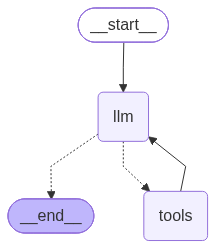

In [15]:
# Escreva sua solução aqui — write_todos, o prompt de sistema e o grafo do coordenador.

# Tarefa 3.3 — write_todos, SYSTEM_COORDENADOR e grafo do coordenador

@tool_decorator
def write_todos(
    todos: List[Todo],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Escreve ou atualiza a lista de tarefas do coordenador.

    Use no início para planejar e sempre que concluir ou replanejar um passo.
    Cada item tem 'descricao' e 'status' ('pendente', 'em_andamento' ou 'concluida').
    """
    resumo = ", ".join(f"{t['descricao']} [{t['status']}]" for t in todos)
    return Command(update={
        "todos": todos,
        "messages": [ToolMessage(
            content=f"Lista de tarefas atualizada com {len(todos)} itens: {resumo}",
            tool_call_id=tool_call_id,
        )],
    })

def carregar_skill(caminho: str = SKILL_PATH) -> str:
    """Carrega o conteúdo completo da skill (frontmatter + corpo)."""
    with open(caminho, encoding="utf-8") as f:
        return f.read()

SYSTEM_COORDENADOR = f"""Você é o coordenador de um deep agent de planejamento de viagem.

Você trabalha em tarefas longas e multi-etapas. Antes de agir, planeje; resultados
longos vão para arquivo; subtarefas especializadas serão delegadas depois.

Ferramentas de gestão:
- write_todos: escreve e atualiza sua lista de tarefas no estado.
- ls, read_file, write_file: listam, leem e gravam arquivos no sistema virtual.

SKILL ATIVA — siga este procedimento ao montar dias de roteiro:

{carregar_skill()}

PROCEDIMENTO DO COORDENADOR

1. Antes de qualquer ação, chame write_todos com o plano completo da tarefa atual.
2. Use as tools locais e MCP apenas quando precisar de dados objetivos.
3. Grave em arquivo (write_file) qualquer resultado extenso — orçamentos, comparações,
   rascunhos de roteiro — e mantenha no contexto apenas o caminho e um resumo curto.
4. Delegue subtarefas especializadas quando as tools de delegação estiverem disponíveis.
5. Após concluir cada passo, chame write_todos novamente marcando o item como concluida.
6. Nunca marque como concluida uma tarefa que não foi executada.

REGRAS

- Respeite sempre as restrições do cenário: mobilidade reduzida e feriado de 15/10.
- Agrupe atividades por proximidade geográfica ao montar roteiros diários.
- Se o plano mudar durante a execução, reescreva a lista com write_todos.
- Prefira ler arquivos com read_file em vez de repetir conteúdo longo no chat.
"""

TOOLS_COORDENADOR = [write_todos, ls, read_file, write_file]
TOOLS_COM_ESTADO = {"ls", "read_file"}
MAPA_COORDENADOR = {t.name: t for t in TOOLS_COORDENADOR}
llm_coordenador = llm.bind_tools(TOOLS_COORDENADOR)

MAX_PASSOS_COORDENADOR = 20

def no_llm_coordenador(state: EstadoViagem) -> Dict[str, Any]:
    """Nó LLM: injeta o prompt de sistema e chama o modelo."""
    mensagens = [SystemMessage(content=SYSTEM_COORDENADOR)] + state["messages"]
    return {"messages": [llm_coordenador.invoke(mensagens)]}

def no_tools_coordenador(state: EstadoViagem) -> Dict[str, Any]:
    """Nó de tools: executa chamadas e consolida Command + ToolMessage."""
    ultima = state["messages"][-1]
    atualizacoes: Dict[str, Any] = {"messages": [], "files": {}}

    for chamada in ultima.tool_calls:
        nome = chamada["name"]

        if nome not in MAPA_COORDENADOR:
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro: tool '{nome}' não existe. Disponíveis: {', '.join(MAPA_COORDENADOR)}",
                tool_call_id=chamada["id"],
            ))
            continue

        chamada_completa = dict(chamada)
        if nome in TOOLS_COM_ESTADO:
            chamada_completa["args"] = {**chamada["args"], "state": state}

        try:
            resultado = MAPA_COORDENADOR[nome].invoke(chamada_completa)
        except Exception as erro:  # noqa: BLE001 — o agente deve ver o erro
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro ao executar '{nome}': {erro}",
                tool_call_id=chamada["id"],
            ))
            continue

        if isinstance(resultado, Command):
            for campo, valor in resultado.update.items():
                if campo == "messages":
                    atualizacoes["messages"].extend(valor)
                elif campo == "files":
                    atualizacoes["files"].update(valor)
                else:
                    atualizacoes[campo] = valor
        else:
            atualizacoes["messages"].append(resultado)

    return atualizacoes

def rotear_coordenador(state: EstadoViagem) -> Literal["tools", "__end__"]:
    """Roteia entre tools e fim, com limite explícito de passos LLM."""
    mensagens = state["messages"]
    ultima = mensagens[-1]

    chamadas_llm = sum(1 for m in mensagens if isinstance(m, AIMessage))
    if chamadas_llm >= MAX_PASSOS_COORDENADOR:
        return END

    return "tools" if getattr(ultima, "tool_calls", None) else END

builder_coordenador = StateGraph(EstadoViagem)
builder_coordenador.add_node("llm", no_llm_coordenador)
builder_coordenador.add_node("tools", no_tools_coordenador)

builder_coordenador.add_edge(START, "llm")
builder_coordenador.add_conditional_edges(
    "llm",
    rotear_coordenador,
    {"tools": "tools", END: END},
)
builder_coordenador.add_edge("tools", "llm")

coordenador = builder_coordenador.compile()
display_graph(coordenador)


### Verificação — Tarefa 3

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [16]:
T = "Tarefa 3 — sistema de arquivos, skill e coordenador"

verificar(T, "EstadoViagem tem os campos esperados",
          {"messages", "todos", "cenario"}.issubset(set(EstadoViagem.__annotations__)),
          str(set(EstadoViagem.__annotations__)))

estado = {"files": {"/destinos.md": "Buenos Aires"}}
verificar(T, "ls lista os arquivos", "/destinos.md" in ls.invoke({"state": estado}))
verificar(T, "read_file lê um arquivo existente",
          read_file.invoke({"caminho": "/destinos.md", "state": estado}) == "Buenos Aires")
verificar(T, "read_file avisa quando o arquivo não existe",
          "erro" in read_file.invoke({"caminho": "/nao_existe.md", "state": estado}).lower())

cmd = write_file.invoke({"name": "write_file", "args": {"caminho": "/x.md", "conteudo": "abc"},
                         "id": "c1", "type": "tool_call"})
verificar(T, "write_file devolve Command", isinstance(cmd, Command))
verificar(T, "write_file grava no campo files", cmd.update.get("files") == {"/x.md": "abc"}, str(cmd.update))

caminho_skill = "skills/montar-dia-de-roteiro.md"
verificar(T, "arquivo da skill foi criado", os.path.exists(caminho_skill))

skill = open(caminho_skill, encoding="utf-8").read() if os.path.exists(caminho_skill) else ""
verificar(T, "skill tem frontmatter com name", "name:" in skill)
verificar(T, "skill tem frontmatter com description", "description:" in skill)
verificar(T, "skill trata a restrição de mobilidade", "mobilidade" in skill.lower())
verificar(T, "skill trata o feriado de 15/10", "feriado" in skill.lower() or "15" in skill)
verificar(T, "skill tem corpo substantivo", len(skill) > 400, f"{len(skill)} caracteres")

cmd = write_todos.invoke({"name": "write_todos",
                          "args": {"todos": [{"descricao": "Escolher destino", "status": "pendente"}]},
                          "id": "c1", "type": "tool_call"})
verificar(T, "write_todos devolve Command", isinstance(cmd, Command))
verificar(T, "write_todos atualiza o campo todos", len(cmd.update.get("todos", [])) == 1, str(cmd.update))

verificar(T, "prompt de sistema carrega o conteúdo da skill",
          any(t in SYSTEM_COORDENADOR.lower() for t in ["mobilidade", "roteiro", "proximidade"]))
verificar(T, "prompt prescreve o uso de write_todos", "write_todos" in SYSTEM_COORDENADOR)
verificar(T, "coordenador é um grafo compilado", isinstance(coordenador, CompiledStateGraph))


[OK]     EstadoViagem tem os campos esperados

[OK]     ls lista os arquivos

[OK]     read_file lê um arquivo existente

[OK]     read_file avisa quando o arquivo não existe

[OK]     write_file devolve Command

...

[OK]     write_todos devolve Command

[OK]     write_todos atualiza o campo todos

[OK]     prompt de sistema carrega o conteúdo da skill

[OK]     prompt prescreve o uso de write_todos

[OK]     coordenador é um grafo compilado

### Decisões de projeto — Tarefa 3

1. **deepagents como infraestrutura, tools da aula como contrato** — Configuramos
   `FilesystemMiddleware` + `StateBackend` conforme o roteiro. As tools expostas
   seguem a API da verificação (`caminho`, `conteudo`, `state`), porque a versão
   0.7.8 do deepagents mudou nomes de parâmetros e exige contexto de runtime.

2. **`write_todos` como `Command`** — O plano vira campo estruturado `todos` no
   estado, inspecionável e sobrevivente à compressão de mensagens (conceito da
   aula de Deep Agents).

3. **Skill como conhecimento procedimental** — Regras de roteiro (proximidade,
   mobilidade, feriado 15/10, atração fechada) ficam na skill, não no código.
   O coordenador carrega o arquivo no prompt de sistema.

4. **Coordenador mínimo nesta etapa** — Só `write_todos` + filesystem. Tools da
   Tarefa 1, MCP e delegação entram nas Tarefas 4–6, mantendo encadeamento.

# Tarefa 4 — Subagente de Orçamento com ReWOO *(25%)*

Este subagente calcula o orçamento da viagem para um destino dado, e usa **ReWOO**.

ReWOO é a escolha certa aqui porque todas as consultas são **independentes e conhecidas de antemão**:
passagem, hospedagem, alimentação e transporte local não dependem umas das outras. Um único planejamento,
execução com substituição de variáveis, e uma síntese. É o padrão mais barato em número de chamadas de LLM.

## 4.1 O planejador

Um nó que produz, em **uma única chamada de LLM**, a lista completa de passos com variáveis:

```text
Plano: buscar o preço da passagem para o destino
#E1 = consultar_voo[Buenos Aires]
Plano: buscar a hospedagem acessível mais barata
#E2 = consultar_hospedagem[Buenos Aires]
Plano: somar o orçamento com os valores obtidos
#E3 = somar_orcamento[#E1, #E2]
```

Use `with_structured_output` com um modelo Pydantic — não faça parsing de texto livre.

## 4.2 O executor

Percorre os passos na ordem, **substituindo as variáveis** `#En` pelos resultados já obtidos, e chama a tool
correspondente. Sem chamada de LLM aqui.

## 4.3 O solver

Uma chamada final de LLM que sintetiza os resultados em um orçamento comentado, e grava em
`/orcamento.md` pelo `write_file`.

## 4.4 A tool de delegação

**`delegar_orcamento(destino, state, tool_call_id)`** — roda o subagente em contexto próprio e devolve ao
coordenador apenas o resumo, com os arquivos gravados. O histórico interno **não** volta.

Você precisará das tools `consultar_voo` e `consultar_hospedagem`, que devem ler `CATALOGO_VOOS`,
`CATALOGO_HOSPEDAGENS` e `CUSTOS_DIARIOS_BRL`. Implemente-as também.

In [33]:
# Escreva sua solução aqui — as tools de catálogo.

# Tarefa 4.1 — Tools de catálogo para o subagente de orçamento

@tool_decorator
def consultar_voo(destino: str, viajantes: int = 2) -> str:
    """Consulta o catálogo fictício de voos para um destino.

    Args:
        destino: Nome da cidade destino (ex.: 'Buenos Aires').
        viajantes: Quantidade de passageiros para calcular o total.

    Returns:
        JSON com dados do voo, incluindo preco_brl (unitário) e preco_total_brl.
    """
    voo = CATALOGO_VOOS.get(destino)
    if voo is None:
        return json.dumps(
            {"erro": "destino_nao_encontrado", "destino": destino},
            ensure_ascii=False,
        )

    preco_unitario = float(voo["preco_brl"])
    return json.dumps({
        "destino": destino,
        "iata": voo["iata"],
        "preco_brl": preco_unitario,
        "preco_total_brl": round(preco_unitario * viajantes, 2),
        "duracao_h": voo["duracao_h"],
        "escalas": voo["escalas"],
        "viajantes": viajantes,
    }, ensure_ascii=False)

@tool_decorator
def consultar_hospedagem(
    destino: str,
    noites: Optional[int] = None,
    dias: Optional[int] = None,
    viajantes: int = 2,
) -> str:
    """Consulta hospedagens e custos diários do destino.

    Prioriza a opção acessível mais barata (restrição de mobilidade reduzida)
    e calcula totais de hospedagem, alimentação e transporte local.

    Args:
        destino: Nome da cidade destino.
        noites: Quantidade de noites (default: cenário fixo).
        dias: Quantidade de dias (default: cenário fixo).
        viajantes: Quantidade de viajantes.

    Returns:
        JSON com opcoes, melhor_acessivel e totais por categoria.
    """
    if noites is None or dias is None:
        periodo = json.loads(calcular_dias.invoke({
            "data_inicio": CENARIO["data_ida"],
            "data_fim": CENARIO["data_volta"],
        }))
        if dias is None:
            dias = periodo["dias"]
        if noites is None:
            noites = periodo["noites"]

    opcoes = CATALOGO_HOSPEDAGENS.get(destino, [])
    custos = CUSTOS_DIARIOS_BRL.get(destino, {})

    if not opcoes:
        return json.dumps(
            {"erro": "destino_nao_encontrado", "destino": destino, "opcoes": []},
            ensure_ascii=False,
        )

    acessiveis = [o for o in opcoes if o.get("acessivel")]
    melhor = min(acessiveis, key=lambda o: o["diaria_brl"]) if acessiveis else None

    alimentacao_unit = float(custos.get("alimentacao", 0.0))
    transporte_unit = float(custos.get("transporte_local", 0.0))

    total_hospedagem = round(melhor["diaria_brl"] * noites, 2) if melhor else 0.0
    total_alimentacao = round(alimentacao_unit * dias * viajantes, 2)
    total_transporte = round(transporte_unit * dias * viajantes, 2)

    return json.dumps({
        "destino": destino,
        "opcoes": opcoes,
        "melhor_acessivel": melhor,
        "custos_diarios_brl": custos,
        "total_hospedagem_brl": total_hospedagem,
        "total_alimentacao_brl": total_alimentacao,
        "total_transporte_brl": total_transporte,
        "noites": noites,
        "dias": dias,
        "viajantes": viajantes,
    }, ensure_ascii=False)

In [34]:
# Escreva sua solução aqui — planejador, executor, solver e o grafo do subagente.

# Tarefa 4.2 — Subagente de Orçamento com ReWOO 
# --- Sub-tarefa 4.2.1 — Nó do planejador (planner) ---

import re
from typing import Union

# --- Modelos estruturados do plano ReWOO ---

class ArgumentoReWOO(BaseModel):
    """Par chave/valor de um argumento de tool no plano ReWOO."""
    chave: str = Field(description="Nome do parâmetro da tool.")
    valor: str = Field(
        description=(
            "Literal ou referência a evidência anterior "
            "(ex.: 'Buenos Aires', '#E1', \"#E2['preco_total_brl']\")."
        )
    )

class PassoReWOO(BaseModel):
    """Um passo do plano: tool + argumentos + variável de saída."""
    variavel: str = Field(description="Variável de saída, ex.: '#E1'.")
    tool: str = Field(description="Nome da tool a executar.")
    argumentos: List[ArgumentoReWOO] = Field(
        description="Argumentos da tool, já com literais ou referências #En."
    )

class PlanoReWOO(BaseModel):
    """Plano completo gerado de uma vez pelo planejador."""
    passos: List[PassoReWOO] = Field(
        description="Passos ordenados; cada um produz uma variável #En."
    )

class EstadoOrcamento(TypedDict):
    """Estado do subagente: compartilha files/cenario e acumula plano/evidências."""
    messages: Annotated[List[BaseMessage], add_messages]
    todos: List[Todo]
    cenario: Dict[str, Any]
    files: Annotated[Dict[str, str], file_reducer]
    plano: List[PassoReWOO]
    evidencias: Dict[str, str]

# --- Tools disponíveis no worker (sem LLM) ---

TOOLS_ORCAMENTO = [
    consultar_voo,
    consultar_hospedagem,
    calcular_dias,
    somar_orcamento,
]
MAPA_TOOLS_ORCAMENTO = {t.name: t for t in TOOLS_ORCAMENTO}

FERRAMENTAS_ORCAMENTO_TEXTO = """
- consultar_voo(destino: str, viajantes: int = 2)
  -> {"preco_brl", "preco_total_brl", "duracao_h", "escalas", ...}
- consultar_hospedagem(destino: str, noites: int, dias: int, viajantes: int = 2)
  -> {"opcoes", "melhor_acessivel", "total_hospedagem_brl",
      "total_alimentacao_brl", "total_transporte_brl", ...}
- calcular_dias(data_inicio: str, data_fim: str)
  -> {"dias", "noites"} ou {"erro": "datas_invalidas"}
- somar_orcamento(passagem_brl: float, hospedagem_brl: float,
                  alimentacao_brl: float, transporte_brl: float)
  -> delega internamente para somar_orcamento(itens=[...])
"""

planejador_orcamento = llm.with_structured_output(PlanoReWOO)

SYSTEM_PLANEJADOR_ORCAMENTO = f"""Você é o planejador ReWOO de um subagente de orçamento de viagem.

Gere o plano COMPLETO de uma vez, sem observar resultados intermediários.

Tools disponíveis:
{FERRAMENTAS_ORCAMENTO_TEXTO}

Regras:
1. Cada passo produz uma variável (#E1, #E2, ...).
2. Valores literais vão como texto (ex.: "Buenos Aires", "2").
3. Referências usam "#En" ou "#En['campo']".
4. Não invente campos fora das assinaturas acima.
5. Use viajantes do cenário quando relevante.
6. Para somar, referencie os totais já calculados nas tools anteriores.

Exemplo de plano válido para Buenos Aires, 2 viajantes, 12-19/10/2026:
- #E1 = calcular_dias(data_inicio="2026-10-12", data_fim="2026-10-19")
- #E2 = consultar_voo(destino="Buenos Aires", viajantes="2")
- #E3 = consultar_hospedagem(
      destino="Buenos Aires",
      noites="#E1['noites']",
      dias="#E1['dias']",
      viajantes="2"
  )
- #E4 = somar_orcamento(
      passagem_brl="#E2['preco_total_brl']",
      hospedagem_brl="#E3['total_hospedagem_brl']",
      alimentacao_brl="#E3['total_alimentacao_brl']",
      transporte_brl="#E3['total_transporte_brl']"
  )
"""

REFERENCIA_RE = re.compile(r"^(#E\d+)(?:\['([\w]+)'\])?$")

def _converter_literal(valor: Any) -> Any:
    """Converte strings numéricas para int/float quando aplicável."""
    if not isinstance(valor, str):
        return valor
    texto = valor.strip()
    if texto.isdigit():
        return int(texto)
    try:
        return float(texto)
    except ValueError:
        return valor

def resolver_valor(valor: str, evidencias: Dict[str, str]) -> Any:
    """Resolve literal ou referência #En / #En['campo']."""
    match = REFERENCIA_RE.match(valor.strip())
    if not match:
        return _converter_literal(valor)

    variavel, campo = match.group(1), match.group(2)
    if variavel not in evidencias:
        return valor

    bruto = evidencias[variavel]
    try:
        dado = json.loads(bruto) if isinstance(bruto, str) else bruto
    except (json.JSONDecodeError, TypeError):
        return bruto

    if campo is None:
        return dado
    if isinstance(dado, dict) and campo in dado:
        return dado[campo]
    return dado

def resolver_argumentos(
    argumentos: List[ArgumentoReWOO],
    evidencias: Dict[str, str],
) -> Dict[str, Any]:
    """Monta o dicionário de argumentos já resolvidos."""
    resolvidos: Dict[str, Any] = {}
    for arg in argumentos:
        if isinstance(arg.valor, str) and arg.valor.strip().startswith("#E"):
            resolvidos[arg.chave] = resolver_valor(arg.valor, evidencias)
        else:
            resolvidos[arg.chave] = _converter_literal(arg.valor)
    return resolvidos

def _montar_tarefa_orcamento(state: EstadoOrcamento) -> str:
    """Extrai a instrução do usuário e enriquece com dados do cenário."""
    ultima = state["messages"][-1]
    texto = ultima.content if isinstance(ultima.content, str) else str(ultima.content)
    cenario = state.get("cenario") or {}
    return (
        f"{texto}\n\n"
        f"Cenário fixo:\n"
        f"- viajantes: {cenario.get('viajantes')}\n"
        f"- data_ida: {cenario.get('data_ida')}\n"
        f"- data_volta: {cenario.get('data_volta')}\n"
        f"- orcamento_total_brl: {cenario.get('orcamento_total_brl')}\n"
        f"- restrições: {cenario.get('restricoes')}"
    )

def no_planner_orcamento(
    state: EstadoOrcamento,
    max_tentativas: int = 3,
) -> Dict[str, Any]:
    """Gera o plano ReWOO em uma única chamada de LLM."""
    mensagens = [
        SystemMessage(content=SYSTEM_PLANEJADOR_ORCAMENTO),
        HumanMessage(content=_montar_tarefa_orcamento(state)),
    ]

    ultimo_erro: Union[str, Exception] = "plano vazio"
    for _ in range(max_tentativas):
        try:
            resposta = planejador_orcamento.invoke(mensagens)
        except Exception as exc:  # noqa: BLE001
            ultimo_erro = exc
            continue

        if resposta is not None and resposta.passos:
            return {"plano": resposta.passos, "evidencias": {}}

        ultimo_erro = "plano vazio ou inválido"

    raise RuntimeError(
        f"Não foi possível gerar plano ReWOO válido. Último erro: {ultimo_erro}"
    )

In [35]:
# Escreva sua solução aqui — planejador, executor, solver e o grafo do subagente.

# Tarefa 4.2 — Subagente de Orçamento com ReWOO 
# --- Sub-tarefa 4.2.2 — Nó do executor (worker) ---

def _executar_tool_orcamento(nome: str, argumentos: Dict[str, Any]) -> str:
    """Executa uma tool do worker, com adaptação para somar_orcamento."""
    if nome == "somar_orcamento":
        itens = [
            {"categoria": "passagem", "valor_brl": float(argumentos["passagem_brl"])},
            {"categoria": "hospedagem", "valor_brl": float(argumentos["hospedagem_brl"])},
            {"categoria": "alimentacao", "valor_brl": float(argumentos["alimentacao_brl"])},
            {"categoria": "transporte_local", "valor_brl": float(argumentos["transporte_brl"])},
        ]
        return somar_orcamento.invoke({"itens": itens})

    if nome not in MAPA_TOOLS_ORCAMENTO:
        return json.dumps({"erro": "tool_desconhecida", "tool": nome}, ensure_ascii=False)

    return MAPA_TOOLS_ORCAMENTO[nome].invoke(argumentos)

def no_worker_orcamento(state: EstadoOrcamento) -> Dict[str, Any]:
    """Executa o plano sem LLM, substituindo variáveis #En."""
    evidencias = dict(state.get("evidencias") or {})

    for passo in state.get("plano") or []:
        argumentos = resolver_argumentos(passo.argumentos, evidencias)
        try:
            resultado = _executar_tool_orcamento(passo.tool, argumentos)
        except Exception as exc:  # noqa: BLE001
            resultado = json.dumps({
                "erro": "falha_ao_executar_tool",
                "tool": passo.tool,
                "argumentos": argumentos,
                "detalhe": str(exc),
            }, ensure_ascii=False)

        evidencias[passo.variavel] = resultado

    return {"evidencias": evidencias}

In [26]:
# Escreva sua solução aqui — planejador, executor, solver e o grafo do subagente.

# Tarefa 4.2 — Subagente de Orçamento com ReWOO 
# --- Sub-tarefa 4.2.3 — Nó do solver (solver) ---

SYSTEM_SOLVER_ORCAMENTO = """Você é o solver de um subagente de orçamento de viagem.

Com base nas evidências coletadas, produza um orçamento comentado em Markdown com:
1. Destino e período da viagem.
2. Tabela ou lista de custos por categoria.
3. Total geral e comparação com o orçamento disponível do cenário.
4. Observação sobre a hospedagem acessível escolhida (mobilidade reduzida).

Seja objetivo, use valores em BRL com duas casas decimais.
Não invente números: use apenas as evidências fornecidas.
"""

def no_solver_orcamento(state: EstadoOrcamento) -> Dict[str, Any]:
    """Sintetiza o orçamento (1 chamada LLM) e grava /orcamento.md via write_file."""
    evidencias_texto = "\n".join(
        f"{var}: {valor}" for var, valor in (state.get("evidencias") or {}).items()
    )
    tarefa = _montar_tarefa_orcamento(state)

    resposta = llm.invoke([
        SystemMessage(content=SYSTEM_SOLVER_ORCAMENTO),
        HumanMessage(content=f"Tarefa:\n{tarefa}\n\nEvidências:\n{evidencias_texto}"),
    ])
    conteudo_md = str(resposta.content)

    cmd = write_file.invoke({
        "name": "write_file",
        "args": {"caminho": "/orcamento.md", "conteudo": conteudo_md},
        "id": "orcamento-solver",
        "type": "tool_call",
    })
    arquivos = cmd.update.get("files", {})

    resumo = "Orçamento calculado e gravado em /orcamento.md."
    if "total_brl" in evidencias_texto:
        resumo += " Consulte o arquivo para o detalhamento completo."

    return {
        "messages": [AIMessage(content=resumo)],
        "files": arquivos,
    }


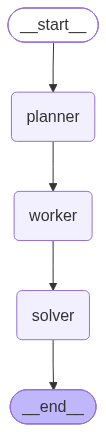

In [36]:
# --- Grafo ReWOO: planejador → worker → solver ---

builder_orcamento = StateGraph(EstadoOrcamento)
builder_orcamento.add_node("planner", no_planner_orcamento)
builder_orcamento.add_node("worker", no_worker_orcamento)
builder_orcamento.add_node("solver", no_solver_orcamento)

builder_orcamento.add_edge(START, "planner")
builder_orcamento.add_edge("planner", "worker")
builder_orcamento.add_edge("worker", "solver")
builder_orcamento.add_edge("solver", END)

subagente_orcamento = builder_orcamento.compile()
display_graph(subagente_orcamento)

In [37]:
# Escreva sua solução aqui — a tool delegar_orcamento.

# Tarefa 4.3 — Delegação ao subagente de orçamento

@tool_decorator
def delegar_orcamento(
    destino: str,
    state: dict,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Delega o cálculo de orçamento ao subagente ReWOO.

    O subagente roda em contexto isolado, grava /orcamento.md e devolve
    apenas um resumo curto ao coordenador (histórico interno não retorna).

    Args:
        destino: Cidade para a qual calcular o orçamento.
        state: Estado parcial com files e cenario.
        tool_call_id: ID da chamada de tool do coordenador.

    Returns:
        Command atualizando files compartilhados e uma única ToolMessage.
    """
    resultado = subagente_orcamento.invoke({
        "messages": [
            HumanMessage(content=f"Calcule o orçamento para {destino}."),
        ],
        "todos": [],
        "files": state.get("files") or {},
        "cenario": state.get("cenario") or CENARIO,
        "plano": [],
        "evidencias": {},
    })

    resposta = str(resultado["messages"][-1].content)

    return Command(update={
        "files": resultado.get("files") or {},
        "messages": [ToolMessage(
            content=f"Subagente de orçamento concluiu {destino}. {resposta}",
            tool_call_id=tool_call_id,
        )],
    })

### Justificativa da Tarefa 4

**Por que ReWOO?** O orçamento segue passos fixos e encadeados por variáveis
(voo → hospedagem → dias → soma). Não há necessidade de replanejar após cada
tool — o padrão minimiza chamadas de LLM (planejador + solver).

**Por que totais nas tools de catálogo?** O `somar_orcamento` da Tarefa 1
espera uma lista de itens; o planner ReWOO trabalha melhor com referências
escalares (`#E2['preco_total_brl']`) do que com expressões ou JSON aninhado.

**Por que hospedagem acessível?** O cenário exige mobilidade reduzida; filtrar
`acessivel=True` e escolher a mais barata é regra de negócio determinística,
não decisão do LLM.

**Delegação:** segue o padrão do deep agent — contexto isolado, filesystem
compartilhado, uma `ToolMessage` de volta ao coordenador.

### Verificação — Tarefa 4

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [38]:
T = "Tarefa 4 — subagente ReWOO"

r = json.loads(consultar_voo.invoke({"destino": "Buenos Aires"}))
verificar(T, "consultar_voo devolve o preço do catálogo", abs(r.get("preco_brl", 0) - 1850.0) < 0.01, str(r))

r = json.loads(consultar_hospedagem.invoke({"destino": "Santiago"}))
verificar(T, "consultar_hospedagem devolve opções", len(r.get("opcoes", r if isinstance(r, list) else [])) >= 1, str(r))

verificar(T, "subagente de orçamento é um grafo compilado", isinstance(subagente_orcamento, CompiledStateGraph))

nos = set(subagente_orcamento.get_graph().nodes)
verificar(T, "grafo tem os três papéis do ReWOO",
          sum(1 for n in nos if any(p in n.lower() for p in ["plan", "exec", "solv", "work"])) >= 3, str(nos))

resultado = subagente_orcamento.invoke({
    "messages": [HumanMessage(content="Calcule o orçamento para Buenos Aires.")],
    "todos": [], "files": {}, "cenario": CENARIO,
})

chamadas_llm = sum(1 for m in resultado["messages"] if isinstance(m, AIMessage))
verificar(T, "ReWOO usa poucas chamadas de LLM (<= 4)", chamadas_llm <= 4, f"{chamadas_llm} chamadas")
verificar(T, "subagente gravou /orcamento.md", "/orcamento.md" in (resultado.get("files") or {}),
          str(list((resultado.get('files') or {}).keys())))

cmd = delegar_orcamento.invoke({
    "name": "delegar_orcamento",
    "args": {"destino": "Buenos Aires", "state": {"files": {}, "cenario": CENARIO}},
    "id": "c1",
    "type": "tool_call",
})
verificar(T, "delegar_orcamento devolve Command", isinstance(cmd, Command))
verificar(T, "delegação devolve arquivos ao coordenador", "/orcamento.md" in (cmd.update.get("files") or {}))
verificar(T, "delegação devolve UMA mensagem ao coordenador", len(cmd.update.get("messages", [])) == 1,
          "o histórico interno do subagente não deve voltar")

[OK]     consultar_voo devolve o preço do catálogo

[OK]     consultar_hospedagem devolve opções

[OK]     subagente de orçamento é um grafo compilado

[OK]     grafo tem os três papéis do ReWOO

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[OK]     ReWOO usa poucas chamadas de LLM (<= 4)

[OK]     subagente gravou /orcamento.md

[OK]     delegar_orcamento devolve Command

[OK]     delegação devolve arquivos ao coordenador

[OK]     delegação devolve UMA mensagem ao coordenador

# Tarefa 5 — Subagente de Destino com Tree of Thoughts *(25%)*

Este subagente escolhe **um** dos três destinos candidatos, e usa **Tree of Thoughts**.

ToT é a escolha certa aqui porque o problema é de **seleção entre alternativas**: gerar candidatos, avaliar
cada um e podar os piores. Não há sequência de ações a planejar — há um espaço de opções a explorar.

## 5.1 A árvore

A árvore tem dois níveis e **seis folhas**:

```text
                        raiz
        ┌────────────────┼────────────────┐
   Buenos Aires      Santiago        Montevidéu
     ┌────┴────┐     ┌────┴────┐     ┌────┴────┐
   gastro.  natureza gastro. natureza gastro. natureza
```

Nível 1: os três destinos candidatos do cenário.
Nível 2: para cada destino, **duas abordagens de viagem** — uma com ênfase em gastronomia e museus, outra com
ênfase em natureza urbana.

## 5.2 Os três nós

**Gerador** — produz as seis folhas, cada uma com uma descrição curta da viagem proposta.

**Avaliador** — pontua cada folha de 0 a 10 em quatro critérios, usando saída estruturada:
custo estimado, clima na janela de datas, aderência aos interesses, e **acessibilidade** (a restrição de
mobilidade reduzida). Use as tools MCP da Tarefa 2 para o clima, e as tools de catálogo da Tarefa 5 para o
custo — a avaliação não pode ser puro chute do modelo.

**Podador** — descarta as folhas abaixo da mediana, escolhe a melhor entre as restantes, e grava a decisão
com a justificativa em `/destinos.md`.

## 5.3 A tool de delegação

**`delegar_destino(state, tool_call_id)`** — mesmo padrão da Tarefa 4.

In [39]:
# Escreva sua solução aqui — os modelos Pydantic da árvore.

# Tarefa 5.1 — Modelos Pydantic da árvore ToT e estado do subagente

import statistics
import concurrent.futures
from typing import Union

AbordagemViagem = Literal["gastronomia e museus", "natureza urbana"]

ABORDAGENS: List[AbordagemViagem] = [
    "gastronomia e museus",
    "natureza urbana",
]

class FolhaViagem(BaseModel):
    """Uma folha da árvore: destino + abordagem + proposta curta."""
    id: str = Field(description="Identificador único, ex.: 'buenos-aires-gastro'.")
    destino: str = Field(description="Cidade candidata.")
    abordagem: AbordagemViagem
    descricao: str = Field(description="Descrição curta da viagem proposta.")

class FolhasGeradas(BaseModel):
    """Saída estruturada do nó gerador — exatamente 6 folhas."""
    folhas: List[FolhaViagem] = Field(
        description="Lista com as 6 folhas (3 destinos x 2 abordagens)."
    )

class PontuacaoCriterios(BaseModel):
    """Quatro critérios de 0 a 10 exigidos pelo roteiro."""
    custo_estimado: float = Field(ge=0, le=10)
    clima: float = Field(ge=0, le=10)
    aderencia_interesses: float = Field(ge=0, le=10)
    acessibilidade: float = Field(ge=0, le=10)

class AvaliacaoFolha(BaseModel):
    """Avaliação estruturada de uma folha."""
    folha_id: str
    destino: str
    abordagem: AbordagemViagem
    criterios: PontuacaoCriterios
    justificativa: str

class AvaliacoesFolhas(BaseModel):
    """Saída estruturada do nó avaliador."""
    avaliacoes: List[AvaliacaoFolha]

class EstadoDestino(TypedDict):
    """Estado do subagente de destino (compartilha files/cenario com o coordenador)."""
    messages: Annotated[List[BaseMessage], add_messages]
    todos: List[Todo]
    cenario: Dict[str, Any]
    files: Annotated[Dict[str, str], file_reducer]
    folhas: List[FolhaViagem]
    avaliacoes: List[AvaliacaoFolha]
    evidencias: Dict[str, Any]

def _executar_async(coro):
    """Executa corrotina mesmo com loop do Jupyter já ativo."""
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        return executor.submit(asyncio.run, coro).result()

def _montar_esqueleto_folhas(candidatos: List[str]) -> List[FolhaViagem]:
    """Gera o esqueleto determinístico das 6 folhas."""
    folhas: List[FolhaViagem] = []
    for destino in candidatos:
        slug = destino.lower().replace(" ", "-")
        for abordagem in ABORDAGENS:
            sufixo = "gastro" if "gastronomia" in abordagem else "natureza"
            folhas.append(FolhaViagem(
                id=f"{slug}-{sufixo}",
                destino=destino,
                abordagem=abordagem,
                descricao="",
            ))
    return folhas

def _score_total(avaliacao: AvaliacaoFolha) -> float:
    """Média dos quatro critérios — critério de desempate do podador."""
    c = avaliacao.criterios
    return (c.custo_estimado + c.clima + c.aderencia_interesses + c.acessibilidade) / 4.0

In [40]:
# Escreva sua solução aqui — gerador, avaliador, podador e o grafo do subagente.

# Tarefa 5.2 — Nós ToT e grafo do subagente de destino
# --- Sub-tarefa 5.2.1 — Nó gerador ---

MAPA_MCP = {t.name: t for t in tools_mcp}

gerador_folhas = llm.with_structured_output(FolhasGeradas)
avaliador_folhas = llm.with_structured_output(AvaliacoesFolhas)

SYSTEM_GERADOR_DESTINO = """Você é o nó GERADOR de um Tree of Thoughts para escolha de destino.

Gere descrições curtas (2-4 frases) para EXATAMENTE as 6 folhas informadas.
Cada folha combina um destino com uma abordagem:
- "gastronomia e museus": ênfase em restaurantes, bairros gastronômicos e museus acessíveis.
- "natureza urbana": parques, costaneras, mirantes e passeios ao ar livre.

Respeite as restrições do cenário:
- mobilidade reduzida (evitar longas caminhadas, priorizar acessibilidade);
- feriado em 15/10/2026 (museus/comércio fechados — programe alternativas nesse dia).

Não altere destino, abordagem nem id das folhas — apenas preencha 'descricao'.
"""

SYSTEM_AVALIADOR_DESTINO = """Você é o nó AVALIADOR de um Tree of Thoughts.

Pontue CADA folha de 0 a 10 nos quatro critérios:
1. custo_estimado — use custo_total_estimado_brl e orçamento do cenário.
2. clima — use dados de prever_clima na janela da viagem.
3. aderencia_interesses — gastronomia, museus, natureza urbana + abordagem da folha.
4. acessibilidade — hospedagem acessível, trajetos curtos, mobilidade reduzida.

Use APENAS as evidências fornecidas; não invente preços nem clima.
Seja mais rigoroso em acessibilidade quando a hospedagem acessível for fraca ou ausente.
"""

async def _coletar_evidencias_destino_async(destino: str, cenario: Dict[str, Any]) -> Dict[str, Any]:
    """Coleta custo (catálogo) e clima (MCP) para um destino."""
    viajantes = int(cenario.get("viajantes", 2))

    voo = json.loads(consultar_voo.invoke({
        "destino": destino,
        "viajantes": viajantes,
    }))
    hosp = json.loads(consultar_hospedagem.invoke({
        "destino": destino,
        "viajantes": viajantes,
    }))

    latitude, longitude = COORDENADAS.get(destino, (None, None))
    geocodificar = MAPA_MCP.get("geocodificar")
    if geocodificar is not None:
        try:
            geo = await geocodificar.ainvoke({"local": destino})
            if isinstance(geo, dict) and "latitude" in geo and "longitude" in geo:
                latitude = float(geo["latitude"])
                longitude = float(geo["longitude"])
        except Exception as exc:  # noqa: BLE001
            geo = {"erro": str(exc)}
    else:
        geo = {"fallback": COORDENADAS.get(destino)}

    clima: Union[Dict[str, Any], str] = {}
    prever_clima = MAPA_MCP.get("prever_clima")
    if prever_clima is not None and latitude is not None and longitude is not None:
        try:
            clima = await prever_clima.ainvoke({
                "latitude": latitude,
                "longitude": longitude,
                "data_inicio": cenario["data_ida"],
                "data_fim": cenario["data_volta"],
            })
        except Exception as exc:  # noqa: BLE001
            clima = {"erro": str(exc)}
    else:
        clima = {"erro": "clima_indisponivel"}

    custo_total = round(
        float(voo.get("preco_total_brl", 0))
        + float(hosp.get("total_hospedagem_brl", 0))
        + float(hosp.get("total_alimentacao_brl", 0))
        + float(hosp.get("total_transporte_brl", 0)),
        2,
    )

    return {
        "destino": destino,
        "voo": voo,
        "hospedagem": hosp,
        "geocodificacao": geo if isinstance(geo, dict) else {"resultado": geo},
        "clima": clima,
        "custo_total_estimado_brl": custo_total,
        "orcamento_total_brl": cenario.get("orcamento_total_brl"),
        "melhor_hospedagem_acessivel": hosp.get("melhor_acessivel"),
    }

def _coletar_evidencias_destino(destino: str, cenario: Dict[str, Any]) -> Dict[str, Any]:
    """Wrapper síncrono para uso nos nós do grafo."""
    return _executar_async(_coletar_evidencias_destino_async(destino, cenario))

def _montar_contexto_tarefa(state: EstadoDestino) -> str:
    """Extrai instrução do usuário enriquecida com o cenário."""
    ultima = state["messages"][-1]
    texto = ultima.content if isinstance(ultima.content, str) else str(ultima.content)
    cenario = state.get("cenario") or CENARIO
    return (
        f"{texto}\n\n"
        f"Cenário:\n{json.dumps(cenario, ensure_ascii=False, indent=2)}"
    )

def no_gerador_destino(state: EstadoDestino) -> Dict[str, Any]:
    """Gera as 6 folhas da árvore (1 chamada LLM com saída estruturada)."""
    cenario = state.get("cenario") or CENARIO
    candidatos = cenario["candidatos"]
    esqueleto = _montar_esqueleto_folhas(candidatos)

    resposta = gerador_folhas.invoke([
        SystemMessage(content=SYSTEM_GERADOR_DESTINO),
        HumanMessage(content=(
            f"Tarefa:\n{_montar_contexto_tarefa(state)}\n\n"
            f"Folhas a preencher:\n"
            f"{json.dumps([f.model_dump() for f in esqueleto], ensure_ascii=False, indent=2)}"
        )),
    ])

    folhas = resposta.folhas if resposta and resposta.folhas else esqueleto

    # Garante estrutura mínima mesmo se o LLM omitir alguma folha
    if len(folhas) != 6:
        por_id = {f.id: f for f in folhas}
        folhas = [
            por_id.get(f.id, f) if f.id not in por_id else por_id[f.id]
            for f in esqueleto
        ]
        for folha in folhas:
            if not folha.descricao:
                folha.descricao = (
                    f"Viagem a {folha.destino} com foco em {folha.abordagem}, "
                    f"respeitando mobilidade reduzida e o feriado de 15/10."
                )

    return {"folhas": folhas, "avaliacoes": [], "evidencias": {}}



In [41]:
# Escreva sua solução aqui — gerador, avaliador, podador e o grafo do subagente.

# Tarefa 5.2 — Nós ToT e grafo do subagente de destino
# --- Sub-tarefa 5.2.2 — Nó avaliador ---

def no_avaliador_destino(state: EstadoDestino) -> Dict[str, Any]:
    """Avalia cada folha com evidências de catálogo + MCP (1 chamada LLM)."""
    cenario = state.get("cenario") or CENARIO
    folhas = state.get("folhas") or []

    evidencias: Dict[str, Any] = {}
    for destino in cenario["candidatos"]:
        evidencias[destino] = _coletar_evidencias_destino(destino, cenario)

    folhas_texto = "\n".join(
        f"- [{f.id}] {f.destino} / {f.abordagem}: {f.descricao}"
        for f in folhas
    )
    evidencias_texto = json.dumps(evidencias, ensure_ascii=False, indent=2)

    resposta = avaliador_folhas.invoke([
        SystemMessage(content=SYSTEM_AVALIADOR_DESTINO),
        HumanMessage(content=(
            f"Folhas:\n{folhas_texto}\n\n"
            f"Evidências por destino:\n{evidencias_texto}\n\n"
            f"Interesses: {cenario.get('interesses')}\n"
            f"Restrições: {cenario.get('restricoes')}"
        )),
    ])

    avaliacoes = resposta.avaliacoes if resposta else []

    # Fallback determinístico se o LLM retornar lista incompleta
    if len(avaliacoes) != len(folhas):
        avaliacoes = []
        for folha in folhas:
            ev = evidencias.get(folha.destino, {})
            custo = float(ev.get("custo_total_estimado_brl", 0))
            orcamento = float(cenario.get("orcamento_total_brl", 12000))
            nota_custo = max(0.0, min(10.0, 10.0 * (1 - custo / orcamento))) if orcamento else 5.0
            acessivel = ev.get("melhor_hospedagem_acessivel") is not None
            avaliacoes.append(AvaliacaoFolha(
                folha_id=folha.id,
                destino=folha.destino,
                abordagem=folha.abordagem,
                criterios=PontuacaoCriterios(
                    custo_estimado=round(nota_custo, 1),
                    clima=7.0,
                    aderencia_interesses=8.0 if "gastronomia" in folha.abordagem else 7.5,
                    acessibilidade=8.5 if acessivel else 4.0,
                ),
                justificativa=(
                    f"Custo estimado R$ {custo:.2f}; "
                    f"acessibilidade {'adequada' if acessivel else 'limitada'}."
                ),
            ))

    return {"avaliacoes": avaliacoes, "evidencias": evidencias}

def _montar_markdown_destinos(
    cenario: Dict[str, Any],
    folhas: List[FolhaViagem],
    avaliacoes: List[AvaliacaoFolha],
    sobreviventes: List[AvaliacaoFolha],
    eliminadas: List[AvaliacaoFolha],
    escolhida: AvaliacaoFolha,
    mediana: float,
) -> str:
    """Monta /destinos.md com todos os candidatos e menção explícita à acessibilidade."""
    linhas = [
        "# Escolha de Destino — Tree of Thoughts",
        "",
        "## Cenário",
        f"- Período: {cenario['data_ida']} a {cenario['data_volta']}",
        f"- Orçamento total: R$ {cenario['orcamento_total_brl']:.2f}",
        f"- Candidatos: {', '.join(cenario['candidatos'])}",
        f"- Interesses: {', '.join(cenario['interesses'])}",
        "- Restrição de **mobilidade reduzida**: evitar trajetos longos a pé e "
        "atrações sem acessibilidade.",
        f"- Feriado local em 15/10/2026: museus e comércio majoritariamente fechados.",
        "",
        "## Árvore explorada (6 folhas)",
    ]

    aval_por_id = {a.folha_id: a for a in avaliacoes}
    for folha in folhas:
        av = aval_por_id.get(folha.id)
        if av is None:
            continue
        c = av.criterios
        linhas.extend([
            "",
            f"### {folha.destino} — {folha.abordagem}",
            folha.descricao,
            f"- Custo estimado: {c.custo_estimado}/10",
            f"- Clima: {c.clima}/10",
            f"- Aderência aos interesses: {c.aderencia_interesses}/10",
            f"- Acessibilidade: {c.acessibilidade}/10",
            f"- Média geral: {_score_total(av):.2f}/10",
            f"- Justificativa: {av.justificativa}",
        ])

    linhas.extend([
        "",
        "## Podagem (mediana)",
        f"- Mediana das médias: **{mediana:.2f}**",
        f"- Folhas eliminadas: {len(eliminadas)}",
        f"- Folhas mantidas: {len(sobreviventes)}",
    ])

    if eliminadas:
        linhas.append(
            "- Eliminadas: "
            + ", ".join(f"{e.destino} ({e.abordagem})" for e in eliminadas)
        )

    linhas.extend([
        "",
        "## Decisão final",
        f"**Destino escolhido:** {escolhida.destino}",
        f"**Abordagem:** {escolhida.abordagem}",
        f"**Pontuação média:** {_score_total(escolhida):.2f}/10",
        "",
        "### Por que esta opção?",
        escolhida.justificativa,
        "",
        "A escolha considerou explicitamente **acessibilidade** para o viajante com "
        "mobilidade reduzida, além de custo, clima e aderência aos interesses "
        "(gastronomia, museus e natureza urbana).",
        "",
        "### Comparação entre candidatos",
    ])

    for destino in cenario["candidatos"]:
        melhor_destino = max(
            (a for a in avaliacoes if a.destino == destino),
            key=_score_total,
            default=None,
        )
        if melhor_destino:
            linhas.append(
                f"- **{destino}**: melhor folha '{melhor_destino.abordagem}' "
                f"com média {_score_total(melhor_destino):.2f}/10 "
                f"(acessibilidade {melhor_destino.criterios.acessibilidade}/10)."
            )

    return "\n".join(linhas)

In [42]:
# Escreva sua solução aqui — gerador, avaliador, podador e o grafo do subagente.

# Tarefa 5.2 — Nós ToT e grafo do subagente de destino
# --- Sub-tarefa 5.2.3 — Nó podador ---

def no_podador_destino(state: EstadoDestino) -> Dict[str, Any]:
    """Descarta folhas abaixo da mediana, escolhe a melhor e grava /destinos.md."""
    cenario = state.get("cenario") or CENARIO
    folhas = state.get("folhas") or []
    avaliacoes = state.get("avaliacoes") or []

    if not avaliacoes:
        raise RuntimeError("Podador chamado sem avaliações.")

    scores = [_score_total(a) for a in avaliacoes]
    mediana = statistics.median(scores)

    sobreviventes = [a for a in avaliacoes if _score_total(a) >= mediana]
    eliminadas = [a for a in avaliacoes if _score_total(a) < mediana]

    if not sobreviventes:
        sobreviventes = avaliacoes

    escolhida = max(sobreviventes, key=_score_total)

    conteudo_md = _montar_markdown_destinos(
        cenario=cenario,
        folhas=folhas,
        avaliacoes=avaliacoes,
        sobreviventes=sobreviventes,
        eliminadas=eliminadas,
        escolhida=escolhida,
        mediana=mediana,
    )

    cmd = write_file.invoke({
        "name": "write_file",
        "args": {"caminho": "/destinos.md", "conteudo": conteudo_md},
        "id": "destino-podador",
        "type": "tool_call",
    })
    arquivos = cmd.update.get("files", {})

    resumo = (
        f"Destino escolhido: {escolhida.destino} "
        f"({escolhida.abordagem}). Análise gravada em /destinos.md."
    )

    return {
        "messages": [AIMessage(content=resumo)],
        "files": arquivos,
    }

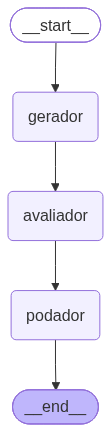

In [43]:
# Escreva sua solução aqui — gerador, avaliador, podador e o grafo do subagente.

# --- Grafo ToT: gerador → avaliador → podador ---

builder_destino = StateGraph(EstadoDestino)
builder_destino.add_node("gerador", no_gerador_destino)
builder_destino.add_node("avaliador", no_avaliador_destino)
builder_destino.add_node("podador", no_podador_destino)

builder_destino.add_edge(START, "gerador")
builder_destino.add_edge("gerador", "avaliador")
builder_destino.add_edge("avaliador", "podador")
builder_destino.add_edge("podador", END)

subagente_destino = builder_destino.compile()
display_graph(subagente_destino)

In [44]:
# Escreva sua solução aqui — a tool delegar_destino.

# Tarefa 5.3 — Delegação ao subagente de destino

@tool_decorator
def delegar_destino(
    state: dict,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Delega a escolha de destino ao subagente ToT.

    O subagente roda em contexto isolado, grava /destinos.md e devolve
    apenas um resumo curto ao coordenador (histórico interno não retorna).

    Args:
        state: Estado parcial com files e cenario.
        tool_call_id: ID da chamada de tool do coordenador.

    Returns:
        Command atualizando files compartilhados e uma única ToolMessage.
    """
    resultado = subagente_destino.invoke({
        "messages": [
            HumanMessage(content="Escolha o destino da viagem."),
        ],
        "todos": [],
        "files": state.get("files") or {},
        "cenario": state.get("cenario") or CENARIO,
        "folhas": [],
        "avaliacoes": [],
        "evidencias": {},
    })

    resposta = str(resultado["messages"][-1].content)

    return Command(update={
        "files": resultado.get("files") or {},
        "messages": [ToolMessage(
            content=f"Subagente de destino concluiu. {resposta}",
            tool_call_id=tool_call_id,
        )],
    })

### Tarefa 5 — Notas de implementação
**Por que ToT e não ReWOO?**
- ReWOO planeja passos sequenciais independentes (passagem → hospedagem → soma).
- Aqui o problema é **seleção entre 6 alternativas** com trade-offs; ToT gera ramos,
  avalia e poda antes de decidir.
**Fluxo do grafo**
1. `gerador` — 1 chamada LLM (`FolhasGeradas`): preenche descrições das 6 folhas fixas.
2. `avaliador` — tools determinísticas (`consultar_voo`, `consultar_hospedagem`,
   `geocodificar`, `prever_clima`) + 1 chamada LLM (`AvaliacoesFolhas`).
3. `podador` — sem LLM: mediana → melhor sobrevivente → `/destinos.md`.
**Custo em LLM:** ~3 chamadas por execução (gerador + avaliador + mensagem final),
adequado para decisão de alto impacto.
**Isolamento na delegação:** `delegar_destino` segue o mesmo contrato da Tarefa 4:
só 1 `ToolMessage` volta ao coordenador; detalhes ficam em `/destinos.md`.

### Verificação — Tarefa 5

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [45]:
T = "Tarefa 5 — subagente ToT"

verificar(T, "subagente de destino é um grafo compilado", isinstance(subagente_destino, CompiledStateGraph))

nos = set(subagente_destino.get_graph().nodes)
verificar(T, "grafo tem os três papéis do ToT",
          sum(1 for n in nos if any(p in n.lower() for p in ["ger", "aval", "pod", "prun", "select"])) >= 3,
          str(nos))

resultado = subagente_destino.invoke({
    "messages": [HumanMessage(content="Escolha o destino da viagem.")],
    "todos": [], "files": {}, "cenario": CENARIO,
})

verificar(T, "subagente gravou /destinos.md", "/destinos.md" in (resultado.get("files") or {}),
          str(list((resultado.get('files') or {}).keys())))

conteudo = (resultado.get("files") or {}).get("/destinos.md", "")
verificar(T, "arquivo cita os três candidatos",
          all(c in conteudo for c in CENARIO["candidatos"]), "as folhas avaliadas devem aparecer")
verificar(T, "arquivo registra um destino escolhido",
          any(c in conteudo for c in CENARIO["candidatos"]) and len(conteudo) > 200,
          f"{len(conteudo)} caracteres")
verificar(T, "avaliação considerou acessibilidade",
          "acess" in conteudo.lower() or "mobilidade" in conteudo.lower())

cmd = delegar_destino.invoke({"name": "delegar_destino",
                              "args": {"state": {"files": {}, "cenario": CENARIO}},
                              "id": "c1", "type": "tool_call"})
verificar(T, "delegar_destino devolve Command", isinstance(cmd, Command))
verificar(T, "delegação devolve UMA mensagem ao coordenador", len(cmd.update.get("messages", [])) == 1)

[OK]     subagente de destino é um grafo compilado

[OK]     grafo tem os três papéis do ToT

Consultando servidor MCP para: geocodificar({'local': 'Buenos Aires'})...

Consultando servidor MCP para: prever_clima({'latitude': -34.6037, 'longitude': -58.3816, 'data_inicio': 
'2026-10-12', 'data_fim': '2026-10-19'})...

Consultando servidor MCP para: geocodificar({'local': 'Santiago'})...

...

[CACHE HIT] Retornando dados em memória para: prever_clima({'latitude': -33.4489, 'longitude': -70.6693, 
'data_inicio': '2026-10-12', 'data_fim': '2026-10-19'})

[CACHE HIT] Retornando dados em memória para: geocodificar({'local': 'Montevidéu'})

[CACHE HIT] Retornando dados em memória para: prever_clima({'latitude': -34.9011, 'longitude': -56.1645, 
'data_inicio': '2026-10-12', 'data_fim': '2026-10-19'})

[OK]     delegar_destino devolve Command

[OK]     delegação devolve UMA mensagem ao coordenador

# Tarefa 6 — Integração *(10%)*

Amarre tudo em um único deep agent e execute a tarefa completa.

O coordenador deve ter acesso a: `write_todos`, `ls`, `read_file`, `write_file`, as tools locais da Tarefa 1,
as tools MCP da Tarefa 2, e as duas tools de delegação. Compile em **`agente_viagem`**.

A tarefa a executar:

> Planeje a viagem descrita no cenário. Escolha o destino, calcule o orçamento e produza um guia final com a
> recomendação, o resumo de custos e as ressalvas sobre as restrições. Grave o guia em `/guia_final.md`.

Depois de executar, imprima o traço em três partes: a **lista de tarefas final**, o **sistema de arquivos**
com o tamanho de cada arquivo, e a **sequência de chamadas de tool**.

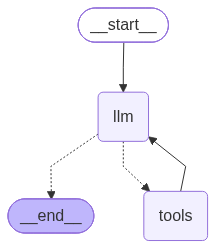

In [46]:
# Escreva sua solução aqui — montagem do agente completo.

# Tarefa 6.1 — Montagem do deep agent integrado

# Reutiliza _executar_async da Tarefa 5 para tools MCP assíncronas no Jupyter.

TOOLS_LOCAIS_VIAGEM = [
    calcular_dias,
    somar_orcamento,
    tempo_deslocamento,
    validar_datas_roteiro,
]
TOOLS_DELEGACAO_VIAGEM = [delegar_destino, delegar_orcamento]

TOOLS_AGENTE_VIAGEM = (
    [write_todos, ls, read_file, write_file]
    + TOOLS_LOCAIS_VIAGEM
    + list(tools_mcp)
    + TOOLS_DELEGACAO_VIAGEM
)

MAPA_AGENTE_VIAGEM = {t.name: t for t in TOOLS_AGENTE_VIAGEM}
TOOLS_COM_ESTADO_VIAGEM = {"ls", "read_file", "delegar_destino", "delegar_orcamento"}
TOOLS_ASYNC_VIAGEM = {t.name for t in tools_mcp}
TOOLS_COMMAND_VIAGEM = {"write_todos", "write_file", "delegar_destino", "delegar_orcamento"}

SYSTEM_AGENTE_VIAGEM = f"""Você é o coordenador de um deep agent de planejamento de viagem.

CENÁRIO (use como fonte de verdade — não altere):
{json.dumps(CENARIO, ensure_ascii=False, indent=2)}

FERRAMENTAS DISPONÍVEIS
- Gestão: write_todos, ls, read_file, write_file
- Cálculo local: calcular_dias, somar_orcamento, tempo_deslocamento, validar_datas_roteiro
- Clima/geo (MCP): geocodificar, prever_clima
- Delegação: delegar_destino(), delegar_orcamento(destino)

SKILL ATIVA — siga ao descrever dias de roteiro no guia:
{carregar_skill()}

PROCEDIMENTO OBRIGATÓRIO (execute nesta ordem)
1. write_todos — planeje com pelo menos 3 tarefas:
   a) escolher destino, b) calcular orçamento, c) produzir guia final.
2. delegar_destino() — subagente ToT grava /destinos.md.
3. read_file("/destinos.md") — identifique o destino recomendado.
4. delegar_orcamento(destino="<cidade escolhida>") — grava /orcamento.md.
5. Leia /destinos.md e /orcamento.md; sintetize o guia.
6. write_file("/guia_final.md", ...) com:
   - recomendação de destino e abordagem;
   - resumo de custos (use dados de /orcamento.md);
   - ressalvas sobre mobilidade reduzida e feriado de 15/10/2026.
7. write_todos — marque TODAS as tarefas como "concluida".

REGRAS
- Planeje antes de agir; resultados longos vão para arquivo.
- No chat, mantenha apenas resumos curtos.
- Não marque tarefa concluída sem executá-la.
- Respeite orçamento e restrições do cenário.
"""

MAX_PASSOS_AGENTE_VIAGEM = 30

llm_agente_viagem = llm.bind_tools(TOOLS_AGENTE_VIAGEM)

def no_llm_agente_viagem(state: EstadoViagem) -> Dict[str, Any]:
    """Nó LLM: injeta prompt de sistema e chama o modelo."""
    mensagens = [SystemMessage(content=SYSTEM_AGENTE_VIAGEM)] + state["messages"]
    return {"messages": [llm_agente_viagem.invoke(mensagens)]}

def _invocar_tool_agente(chamada: dict, state: EstadoViagem) -> Any:
    """Executa tool síncrona, assíncrona (MCP) ou que devolve Command."""
    nome = chamada["name"]
    tool = MAPA_AGENTE_VIAGEM[nome]
    args = dict(chamada.get("args") or {})

    if nome in TOOLS_COM_ESTADO_VIAGEM:
        args["state"] = state

    chamada_completa = {**chamada, "args": args}

    if nome in TOOLS_ASYNC_VIAGEM:
        return _executar_async(tool.ainvoke(args))
    if nome in TOOLS_COMMAND_VIAGEM:
        return tool.invoke(chamada_completa)
    return tool.invoke(args)

def no_tools_agente_viagem(state: EstadoViagem) -> Dict[str, Any]:
    """Nó de tools: executa chamadas e consolida Command + ToolMessage."""
    ultima = state["messages"][-1]
    atualizacoes: Dict[str, Any] = {"messages": [], "files": {}}

    for chamada in ultima.tool_calls:
        nome = chamada["name"]

        if nome not in MAPA_AGENTE_VIAGEM:
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro: tool '{nome}' indisponível.",
                tool_call_id=chamada["id"],
            ))
            continue

        try:
            resultado = _invocar_tool_agente(chamada, state)
        except Exception as erro:  # noqa: BLE001
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro ao executar '{nome}': {erro}",
                tool_call_id=chamada["id"],
            ))
            continue

        if isinstance(resultado, Command):
            for campo, valor in resultado.update.items():
                if campo == "messages":
                    atualizacoes["messages"].extend(valor)
                elif campo == "files":
                    atualizacoes["files"].update(valor)
                else:
                    atualizacoes[campo] = valor
        else:
            atualizacoes["messages"].append(ToolMessage(
                content=str(resultado),
                tool_call_id=chamada["id"],
            ))

    return atualizacoes

def rotear_agente_viagem(state: EstadoViagem) -> Literal["tools", "__end__"]:
    """Roteia entre tools e fim, com limite explícito de passos."""
    mensagens = state["messages"]
    ultima = mensagens[-1]
    chamadas_llm = sum(1 for m in mensagens if isinstance(m, AIMessage))

    if chamadas_llm >= MAX_PASSOS_AGENTE_VIAGEM:
        return END
    return "tools" if getattr(ultima, "tool_calls", None) else END

builder_agente_viagem = StateGraph(EstadoViagem)
builder_agente_viagem.add_node("llm", no_llm_agente_viagem)
builder_agente_viagem.add_node("tools", no_tools_agente_viagem)
builder_agente_viagem.add_edge(START, "llm")
builder_agente_viagem.add_conditional_edges(
    "llm", rotear_agente_viagem, {"tools": "tools", END: END},
)
builder_agente_viagem.add_edge("tools", "llm")

agente_viagem = builder_agente_viagem.compile()
display_graph(agente_viagem)

In [47]:
# Escreva sua solução aqui — execução da tarefa e traço.

# Tarefa 6.2 — Execução da tarefa completa e traço de execução

PROMPT_VIAGEM = (
    "Planeje a viagem descrita no cenário. Escolha o destino, calcule o orçamento "
    "e produza um guia final com a recomendação, o resumo de custos e as "
    "ressalvas sobre as restrições. Grave o guia em /guia_final.md."
)

estado_final_demo = agente_viagem.invoke({
    "messages": [HumanMessage(content=PROMPT_VIAGEM)],
    "todos": [],
    "files": {},
    "cenario": CENARIO,
})

# --- Traço 1: lista de tarefas final ---
print("=" * 60)
print("LISTA DE TAREFAS FINAL")
print("=" * 60)
for item in estado_final_demo.get("todos") or []:
    print(f"  [{item['status']:>12}] {item['descricao']}")

# --- Traço 2: sistema de arquivos com tamanhos ---
print("\n" + "=" * 60)
print("SISTEMA DE ARQUIVOS")
print("=" * 60)
arquivos_demo = estado_final_demo.get("files") or {}
for caminho in sorted(arquivos_demo):
    print(f"  {caminho}: {len(arquivos_demo[caminho])} caracteres")

# --- Traço 3: sequência de chamadas de tool ---
print("\n" + "=" * 60)
print("SEQUÊNCIA DE CHAMADAS DE TOOL")
print("=" * 60)
for msg in estado_final_demo["messages"]:
    if isinstance(msg, AIMessage) and msg.tool_calls:
        for tc in msg.tool_calls:
            args_txt = json.dumps(tc.get("args") or {}, ensure_ascii=False)
            if len(args_txt) > 120:
                args_txt = args_txt[:117] + "..."
            print(f"  -> {tc['name']}({args_txt})")

# Métrica de descarregamento (mesma lógica da verificação)
tokens_ctx = contar_tokens_aproximado(estado_final_demo["messages"])
total_chars = sum(len(c) for c in arquivos_demo.values())
print(
    f"\nContexto ~{tokens_ctx} tokens | Arquivos {total_chars} caracteres | "
    f"Descarregamento: {'sim' if total_chars > tokens_ctx else 'não'}"
)

[CACHE HIT] Retornando dados em memória para: geocodificar({'local': 'Buenos Aires'})

[CACHE HIT] Retornando dados em memória para: prever_clima({'latitude': -34.6037, 'longitude': -58.3816, 
'data_inicio': '2026-10-12', 'data_fim': '2026-10-19'})

[CACHE HIT] Retornando dados em memória para: geocodificar({'local': 'Santiago'})

[CACHE HIT] Retornando dados em memória para: prever_clima({'latitude': -33.4489, 'longitude': -70.6693, 
'data_inicio': '2026-10-12', 'data_fim': '2026-10-19'})

[CACHE HIT] Retornando dados em memória para: geocodificar({'local': 'Montevidéu'})

...

-> delegar_orcamento({"destino": "Buenos Aires", "state": {}})

-> read_file({"caminho": "/orcamento.md"})

-> write_file({"conteudo": "# Guia Completo de Planejamento de Viagem: Buenos Aires\n\n---\n\n## 1. Recomendação 
de Destino e Abord...)

-> write_todos({"todos": [{"status": "concluida", "descricao": "Escolher destino via subagente ToT"}, {"status": 
"concluida", "descr...)

Contexto ~6082 tokens | Arquivos 19773 caracteres | Descarregamento: sim

### Tarefa 6 — Notas de implementação

**Arquitetura:** o `agente_viagem` é um deep agent com loop ReAct no `EstadoViagem`.
O coordenador orquestra tools locais (T1), MCP (T2), filesystem/skill (T3) e
delegações ReWOO/ToT (T4/T5).

**Por que delegar em vez de calcular no coordenador?**
- Isolamento de contexto: subagentes geram histórico longo; só 1 `ToolMessage`
  volta ao coordenador.
- Descarregamento: detalhes ficam em `/destinos.md` e `/orcamento.md`; o guia
  final consolida via `read_file`.

**Fluxo esperado:**
`write_todos` → `delegar_destino` → `delegar_orcamento` → `write_file(/guia_final.md)` → `write_todos(concluida)`

**Descarregamento de contexto:** arquivos somam mais caracteres que o histórico
de mensagens — padrão deep agent (contexto curto + memória em arquivo).

### Verificação — Tarefa 6

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [48]:
T = "Tarefa 6 — integração"

verificar(T, "agente_viagem é um grafo compilado", isinstance(agente_viagem, CompiledStateGraph))

final = agente_viagem.invoke({
    "messages": [HumanMessage(content=(
        "Planeje a viagem descrita no cenário. Escolha o destino, calcule o orçamento e produza um guia "
        "final com a recomendação, o resumo de custos e as ressalvas sobre as restrições. "
        "Grave o guia em /guia_final.md."
    ))],
    "todos": [], "files": {}, "cenario": CENARIO,
})

arquivos = final.get("files") or {}
verificar(T, "o agente produziu o guia final", "/guia_final.md" in arquivos, str(list(arquivos)))
verificar(T, "o agente delegou a escolha de destino", "/destinos.md" in arquivos)
verificar(T, "o agente delegou o orçamento", "/orcamento.md" in arquivos)
verificar(T, "o agente escreveu uma lista de tarefas", len(final.get("todos") or []) >= 3,
          str(final.get("todos")))
verificar(T, "todas as tarefas foram encerradas",
          all(t.get("status") == "concluida" for t in (final.get("todos") or [{}])),
          "verifique se o agente marcou o progresso")

tokens_ctx = contar_tokens_aproximado(final["messages"])
total_arquivos = sum(len(c) for c in arquivos.values())
verificar(T, "houve descarregamento de contexto", total_arquivos > tokens_ctx,
          f"contexto ~{tokens_ctx} tokens, arquivos {total_arquivos} caracteres")

resumo_verificacoes()

[OK]     agente_viagem é um grafo compilado

[CACHE HIT] Retornando dados em memória para: geocodificar({'local': 'Buenos Aires'})

[CACHE HIT] Retornando dados em memória para: prever_clima({'latitude': -34.6037, 'longitude': -58.3816, 
'data_inicio': '2026-10-12', 'data_fim': '2026-10-19'})

[CACHE HIT] Retornando dados em memória para: geocodificar({'local': 'Santiago'})

[CACHE HIT] Retornando dados em memória para: prever_clima({'latitude': -33.4489, 'longitude': -70.6693, 
'data_inicio': '2026-10-12', 'data_fim': '2026-10-19'})

...

Tarefa 2 — integração MCP          3/3 critérios

Tarefa 3 — sistema de arquivos, skill e coordenador 17/17 critérios

Tarefa 4 — subagente ReWOO         11/11 critérios

Tarefa 5 — subagente ToT           8/8 critérios

Tarefa 6 — integração              7/7 critérios

# 7. Checklist de entrega

Antes de entregar, verifique:

1. Todas as células foram executadas **na ordem**, e as saídas estão salvas no notebook.
2. A célula `resumo_verificacoes()` ao final da Tarefa 6 foi executada e a saída está visível.
3. O arquivo `skills/montar-dia-de-roteiro.md` está junto do notebook, assim como a configuração do
   servidor MCP usado na Tarefa 2 (comando/argumentos), se relevante para reproduzir sua execução.
4. As questões da análise crítica (Seção 7) estão respondidas.
5. As especificações escritas da Seção 8 (Plan-and-Execute e Reflection) estão preenchidas.
6. Nenhum valor do dicionário `CENARIO` foi alterado.
7. O arquivo segue o padrão de nome descrito na Seção 0.3 — Submissão.
